# Credit-Card Transaction Fraud Detection — Leakage-Safe, Time-Aware ML Pipeline

**Role:** Senior ML / Fraud Analytics / MLOps portfolio workflow  
**Task:** Binary classification — `0 = legitimate`, `1 = fraudulent`  
**Dataset:** Kaggle `ealtman2019/credit-card-transactions`

## Final methodology

This version treats fraud detection as a **temporal prediction problem** rather than a generic random-split classification task.

- The latest 20% of transactions form the **untouched future test set**.
- The preceding 20% form the **validation set** for model selection.
- The earliest period is the **development/training data** used for fitting and time-series cross-validation.
- Hyperparameter tuning uses **PR-AUC / Average Precision** as the primary metric because fraud is extremely rare.
- Threshold selection happens only after model selection and never uses the final test set.
- The final model is refit on all pre-test development data before one final future-period evaluation.
- Preprocessing and SMOTE remain inside pipelines so learned transformations are fitted only on the relevant training folds.
- The notebook reports temporal robustness explicitly instead of hiding optimistic random-split performance.

**Important:** this is a production-oriented portfolio project, not a clinically or financially approved production system. Real deployment requires organization-specific validation, data governance, monitoring, security, and model-risk approval.


# 1. Environment Setup

Install dependencies once, if needed (the line is commented out so the notebook runs headlessly):

In [1]:
# Reproducible environment setup
# Install dependencies outside the notebook for a clean, pinned environment:
#     python -m pip install -r requirements.txt
#
# The notebook intentionally does not upgrade packages at runtime.
print("Environment setup assumes the dependencies in requirements.txt are installed.")


Environment setup assumes the dependencies in requirements.txt are installed.


In [2]:

import os
import re
import sys
import json
import time
import platform
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import imblearn
import joblib
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    brier_score_loss,
)
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.calibration import calibration_curve
from sklearn.pipeline import Pipeline as SklearnPipeline   # used inside ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline                      # sampler-aware pipeline for the models

sklearn_major_minor = tuple(int(part) for part in sklearn.__version__.split(".")[:2])
assert sklearn_major_minor >= (1, 2), (
    f"scikit-learn >= 1.2 is required (found {sklearn.__version__}) for dense OneHotEncoder "
    "output and HistGradientBoosting class weights."
)
assert sys.version_info >= (3, 10), "Python 3.10+ is required."

# Clean, professional plotting defaults
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.frameon": False,
})
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print(f"Python {platform.python_version()} | numpy {np.__version__} | pandas {pd.__version__} | "
      f"scikit-learn {sklearn.__version__} | imbalanced-learn {imblearn.__version__}")

Python 3.13.5 | numpy 2.5.3 | pandas 3.0.6 | scikit-learn 1.9.1 | imbalanced-learn 0.14.2


# 2. Reproducibility Configuration

One global seed is used everywhere it is supported (splits, models, CV shuffling, SMOTE, sampling).

The dataset is very large (tens of millions of rows in the main file), so loading uses a **random row sample that preserves the fraud prevalence** (`SAMPLE_FRACTION`). Set it to `1.0` to use everything if you have the memory and time.

All run-size controls can also be set through environment variables for headless runs (`FRAUD_NB_FAST_MODE=1`, `FRAUD_NB_SAMPLE_FRACTION=0.02`, `FRAUD_NB_LOCAL_CSV=/path/file.csv`).

In [3]:
# ---------------- Reproducibility ----------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---------------- Run-size controls ----------------
FAST_MODE = os.environ.get("FRAUD_NB_FAST_MODE", "0") == "1"
SAMPLE_FRACTION = float(os.environ.get("FRAUD_NB_SAMPLE_FRACTION", 0.01 if FAST_MODE else 0.05))
CHUNK_SIZE = 1_000_000
MAX_TRAIN_ROWS = 75_000 if FAST_MODE else 300_000
PERMUTATION_MAX_ROWS = 10_000 if FAST_MODE else 100_000
CV_FOLDS = 4
OOF_FOLDS = 4

# ---------------- Data source ----------------
KAGGLE_HANDLE = "ealtman2019/credit-card-transactions"
TRANSACTION_FILE = "credit_card_transactions-ibm_v2.csv"
LOCAL_CSV_PATH = os.environ.get("FRAUD_NB_LOCAL_CSV")
ALLOW_NONRANDOM_FALLBACK = False  # never silently replace a random sample with the first rows

# ---------------- Temporal evaluation ----------------
TEST_SIZE = 0.20  # latest 20% of time = final future test
VAL_SIZE = 0.20   # preceding 20% = validation

# ---------------- Feature policy ----------------
MAX_CATEGORICAL_CARDINALITY = 300
MIN_CATEGORY_FREQUENCY = 30
HIGH_MISSING_THRESHOLD = 0.20
ACCOUNT_ID_COLUMNS = ["User", "Card"]
IDENTIFIER_COLUMNS = ["MerchantName", "Zip"]
TEMPORAL_EXCLUDED_COLUMNS = ["TransactionTimestamp", "TimeStep", "Year"]

# ---------------- Imbalance handling ----------------
SMOTE_SAMPLING_STRATEGY = 0.05

# ---------------- Threshold policy ----------------
TARGET_RECALL = 0.90
THRESHOLD_STRATEGY = "max_f1"  # "max_f1" | "recall_target" | "min_cost"

# ---------------- Business-cost ASSUMPTIONS ----------------
# Relative units only. Replace with organization-specific estimates before operational use.
COST_FALSE_NEGATIVE = 100.0
COST_FALSE_POSITIVE = 1.0

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

print(f"FAST_MODE={FAST_MODE} | SAMPLE_FRACTION={SAMPLE_FRACTION} | MAX_TRAIN_ROWS={MAX_TRAIN_ROWS:,}")
print(f"Primary evaluation: chronological train -> validation -> future test | threshold={THRESHOLD_STRATEGY}")


FAST_MODE=False | SAMPLE_FRACTION=0.05 | MAX_TRAIN_ROWS=300,000
Primary evaluation: chronological train -> validation -> future test | threshold=max_f1


# 3. Dataset Loading

`kagglehub.dataset_download` fetches the files, then the main transaction CSV is read in chunks and **randomly sampled** so memory stays bounded and the fraud rate is preserved. (`KaggleDatasetAdapter.PANDAS` with `kagglehub.load_dataset(...)` would load the *entire* file into memory; it is kept as an automatic fallback that reads only the first `FALLBACK_NROWS` rows.)

The Kaggle dataset ships several CSVs (transactions, users, cards). The transaction file is chosen by name, falling back to the largest non-auxiliary CSV, and the choice is printed so you can verify it.

In [4]:
def find_transaction_csv(root: Path, preferred: str) -> Path:
    """Locate the transaction CSV inside a downloaded Kaggle dataset directory."""
    csv_files = sorted(root.rglob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found under {root}")

    listing = pd.DataFrame({
        "file": [f.name for f in csv_files],
        "size_MB": [f.stat().st_size / 1e6 for f in csv_files],
    })
    print("CSV files in dataset:")
    display(listing)

    for f in csv_files:
        if f.name == preferred:
            return f

    pool = [f for f in csv_files if not f.name.lower().startswith(("sd254", "user"))] or csv_files
    chosen = max(pool, key=lambda f: f.stat().st_size)
    print(f"Preferred file '{preferred}' not found; using largest transaction candidate '{chosen.name}'.")
    return chosen


def load_sampled_transactions(csv_path: Path, fraction: float, chunk_size: int, seed: int):
    """Read a large CSV in chunks using a deterministic row sample."""
    if fraction >= 1.0:
        frame = pd.read_csv(csv_path, low_memory=False)
        return frame, len(frame)

    parts, rows_read = [], 0
    for i, chunk in enumerate(pd.read_csv(csv_path, chunksize=chunk_size, low_memory=False)):
        rows_read += len(chunk)
        parts.append(chunk.sample(frac=fraction, random_state=seed + i).sort_index())
    return pd.concat(parts, ignore_index=True), rows_read


rows_in_source = None
if LOCAL_CSV_PATH:
    csv_path = Path(LOCAL_CSV_PATH)
    if not csv_path.exists():
        raise FileNotFoundError(f"FRAUD_NB_LOCAL_CSV does not exist: {csv_path}")
    raw_df, rows_in_source = load_sampled_transactions(csv_path, SAMPLE_FRACTION, CHUNK_SIZE, RANDOM_STATE)
    data_source_note = f"local file {csv_path.name}"
else:
    try:
        import kagglehub
        dataset_root = Path(kagglehub.dataset_download(KAGGLE_HANDLE))
        csv_path = find_transaction_csv(dataset_root, TRANSACTION_FILE)
        raw_df, rows_in_source = load_sampled_transactions(csv_path, SAMPLE_FRACTION, CHUNK_SIZE, RANDOM_STATE)
        data_source_note = f"kagglehub download, file {csv_path.name}"
    except Exception as download_error:
        if not ALLOW_NONRANDOM_FALLBACK:
            raise RuntimeError(
                "Dataset download failed. Set FRAUD_NB_LOCAL_CSV to a local copy of "
                f"{TRANSACTION_FILE} or enable ALLOW_NONRANDOM_FALLBACK explicitly.\n"
                f"Original error: {type(download_error).__name__}: {download_error}"
            ) from download_error
        raise RuntimeError("Non-random fallback is disabled in the final notebook.")

print(f"\nSource: {data_source_note}")
if rows_in_source is not None:
    print(f"Rows in source file: {rows_in_source:,} | rows kept: {len(raw_df):,} "
          f"({len(raw_df) / rows_in_source:.2%})")
print("\nFirst 5 records:")
display(raw_df.head())


C:\Users\moham\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CSV files in dataset:


,file,size_MB
0,credit_card_transactions-ibm_v2.csv,"2,350.7441"
1,sd254_cards.csv,0.4871
2,sd254_users.csv,0.2244
3,User0_credit_card_transactions.csv,1.8993



Source: kagglehub download, file credit_card_transactions-ibm_v2.csv
Rows in source file: 24,386,900 | rows kept: 1,219,345 (5.00%)

First 5 records:


,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,"91,750.0000",5300,NaN,No
1,0,0,2002,9,7,06:34,$45.30,Swipe Transaction,-5475680618560174533,Monterey Park,CA,"91,755.0000",5942,NaN,No
2,0,0,2002,9,11,13:06,$62.06,Swipe Transaction,2027553650310142703,Mira Loma,CA,"91,752.0000",5541,NaN,No
3,0,0,2002,9,22,06:50,$47.51,Swipe Transaction,4060646732831064559,La Verne,CA,"91,750.0000",5411,NaN,No
4,0,0,2002,9,28,06:23,$141.70,Swipe Transaction,5817218446178736267,La Verne,CA,"91,750.0000",5912,NaN,No


# 4. Data Validation and Schema Inspection

First the **raw** data is inspected exactly as loaded: shape, types, missingness, duplicates and cardinality. Only afterwards is the schema mapped to canonical names.

In [5]:
print(f"Shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns\n")
print("Column names:")
print(list(raw_df.columns), "\n")
print("df.info():")
raw_df.info()

n_duplicates = int(raw_df.duplicated().sum())
print(f"\nDuplicate rows: {n_duplicates:,} ({n_duplicates / len(raw_df):.4%})")

profile = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "missing_n": raw_df.isna().sum(),
    "missing_pct": raw_df.isna().mean() * 100,
    "n_unique": raw_df.nunique(dropna=True),
})
print("\nColumn profile (types, missing values, unique values):")
display(profile)

numeric_raw = raw_df.select_dtypes(include=[np.number])
inf_counts = np.isinf(numeric_raw).sum()
print("\nColumns containing +/-inf values:", inf_counts[inf_counts > 0].to_dict() or "none")

Shape: 1,219,345 rows x 15 columns

Column names:
['User', 'Card', 'Year', 'Month', 'Day', 'Time', 'Amount', 'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC', 'Errors?', 'Is Fraud?'] 

df.info():
<class 'pandas.DataFrame'>
RangeIndex: 1219345 entries, 0 to 1219344
Data columns (total 15 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   User            1219345 non-null  int64  
 1   Card            1219345 non-null  int64  
 2   Year            1219345 non-null  int64  
 3   Month           1219345 non-null  int64  
 4   Day             1219345 non-null  int64  
 5   Time            1219345 non-null  str    
 6   Amount          1219345 non-null  str    
 7   Use Chip        1219345 non-null  str    
 8   Merchant Name   1219345 non-null  int64  
 9   Merchant City   1219345 non-null  str    
 10  Merchant State  1083400 non-null  str    
 11  Zip             1075575 non-null  float64
 12  MCC        

,dtype,missing_n,missing_pct,n_unique
User,int64,0,0.0000,1992
Card,int64,0,0.0000,9
Year,int64,0,0.0000,30
Month,int64,0,0.0000,12
Day,int64,0,0.0000,31
Time,str,0,0.0000,1440
Amount,str,0,0.0000,36080
Use Chip,str,0,0.0000,3
Merchant Name,int64,0,0.0000,36059
Merchant City,str,0,0.0000,9856



Columns containing +/-inf values: none


### Target and schema mapping

The expected target is `IsFraud`. Real datasets often use different names or encodings (for example `"Is Fraud?"` with `Yes`/`No`). The code below finds the actual target column, encodes it to `0/1`, and **documents every rename**. It never fabricates a column: anything that cannot be mapped is reported as missing.

In [6]:
TARGET = "IsFraud"

# Known renames for the IBM/TabFormer-style schema. Applied only where the source column exists.
KNOWN_RENAMES = {
    "Is Fraud?": "IsFraud",
    "Amount": "TransactionAmount",
    "Use Chip": "TransactionType",
    "MCC": "MerchantCategory",
    "Merchant Name": "MerchantName",
    "Merchant City": "MerchantCity",
    "Merchant State": "MerchantState",
    "Errors?": "Errors",
}
TARGET_ALIASES = ["IsFraud", "Is Fraud?", "is_fraud", "isFraud", "Fraud", "Class", "label"]
TRUE_TOKENS = {"1", "yes", "y", "true", "t", "fraud"}
FALSE_TOKENS = {"0", "no", "n", "false", "f", "legit", "legitimate"}


def _normalise_name(name: str) -> str:
    return re.sub(r"[^a-z0-9]", "", str(name).lower())


def find_target_column(columns) -> str:
    """Return the column holding the fraud label, matching aliases case- and punctuation-insensitively."""
    lookup = {_normalise_name(c): c for c in columns}
    for alias in TARGET_ALIASES:
        if _normalise_name(alias) in lookup:
            return lookup[_normalise_name(alias)]
    raise KeyError(f"No target column found. Tried aliases {TARGET_ALIASES}. Available columns: {list(columns)}")


def encode_target(series: pd.Series) -> pd.Series:
    """Encode a fraud label (bool / 0-1 / Yes-No style strings) to int 0/1, failing loudly on anything else."""
    if pd.api.types.is_bool_dtype(series):
        return series.astype("int8")
    if pd.api.types.is_numeric_dtype(series):
        bad = set(series.dropna().unique()) - {0, 1}
        if bad:
            raise ValueError(f"Numeric target contains values other than 0/1: {sorted(bad)[:10]}")
        return series.astype("float").astype("Int8")
    tokens = series.astype("string").str.strip().str.lower()
    mapping = {**{t: 1 for t in TRUE_TOKENS}, **{t: 0 for t in FALSE_TOKENS}}
    encoded = tokens.map(mapping)
    unmapped = tokens[encoded.isna() & tokens.notna()].unique()
    if len(unmapped):
        raise ValueError(f"Unrecognised target labels: {list(unmapped)[:10]}")
    return encoded.astype("Int8")


target_source_column = find_target_column(raw_df.columns)
print(f"Target column detected: '{target_source_column}'")
print("Raw target values:", raw_df[target_source_column].value_counts(dropna=False).to_dict())

df = raw_df.copy()
df.columns = df.columns.str.strip()
target_source_column = target_source_column.strip()

rename_map = {old: new for old, new in KNOWN_RENAMES.items() if old in df.columns and new not in df.columns}
rename_map.setdefault(target_source_column, TARGET)
if target_source_column == TARGET:
    rename_map.pop(TARGET, None)
df = df.rename(columns=rename_map)

n_missing_target = int(df[TARGET].isna().sum())
if n_missing_target:
    print(f"WARNING: dropping {n_missing_target:,} rows with a missing target label.")
    df = df.loc[df[TARGET].notna()].copy()
df[TARGET] = encode_target(df[TARGET]).astype("int8")

assert "IsFraud" in df.columns, "Target column IsFraud was not created."
assert set(df["IsFraud"].unique()) <= {0, 1}, "Target must be binary 0/1."

schema_mapping = pd.DataFrame(
    [{"original_column": old, "canonical_column": new} for old, new in rename_map.items()]
)
print("\nSchema mapping applied (original -> canonical):")
display(schema_mapping)

Target column detected: 'Is Fraud?'
Raw target values: {'No': 1217864, 'Yes': 1481}

Schema mapping applied (original -> canonical):


,original_column,canonical_column
0,Is Fraud?,IsFraud
1,Amount,TransactionAmount
2,Use Chip,TransactionType
3,MCC,MerchantCategory
4,Merchant Name,MerchantName
5,Merchant City,MerchantCity
6,Merchant State,MerchantState
7,Errors?,Errors


### Stateless feature preparation

Only **row-wise, label-free** transformations happen before the split. They learn nothing from the data distribution, so they cannot leak:

* Currency strings such as `"$12.34"` → numeric amounts (refunds are negative).
* `LogAbsAmount` — signed log transform for the heavy right tail, defined for negative amounts too (`log1p` alone is not).
* Time parsing → `Hour`, `Minute`, `DayOfWeek`, `TransactionTimestamp`, and `TimeStep` (hours since the first transaction, **derived**, used for temporal splitting and excluded from model features).
* Numeric code columns that are really categories (`MerchantCategory`) are cast to strings.
* `±inf` → `NaN`, and all missing markers in text columns are normalised to `np.nan`.

**Not done here on purpose:** any aggregate such as "user's average amount" or "merchant fraud rate". Those must be computed strictly from past data and inside a time-aware pipeline, otherwise they leak (see the leakage section).

In [7]:
def signed_log1p(values: pd.Series) -> pd.Series:
    """Symmetric log transform: sign(x) * log1p(|x|). Handles refunds (negative amounts)."""
    return np.sign(values) * np.log1p(np.abs(values))


def to_numeric_amount(series: pd.Series) -> pd.Series:
    """Convert '$1,234.50' / '-$77.00' style strings to float; numeric input passes through."""
    if pd.api.types.is_numeric_dtype(series):
        return series.astype("float64")
    cleaned = series.astype("string").str.replace(r"[$,\s]", "", regex=True)
    return pd.to_numeric(cleaned, errors="coerce")


def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Stateless, label-free feature preparation. Safe to run before the train/test split."""
    out = frame.copy()

    if "TransactionAmount" in out.columns:
        out["TransactionAmount"] = to_numeric_amount(out["TransactionAmount"])
        out["LogAbsAmount"] = signed_log1p(out["TransactionAmount"])

    if "Time" in out.columns:
        hhmm = out["Time"].astype("string").str.extract(r"^\s*(\d{1,2}):(\d{2})")
        out["Hour"] = pd.to_numeric(hhmm[0], errors="coerce")
        out["Minute"] = pd.to_numeric(hhmm[1], errors="coerce")
        out = out.drop(columns=["Time"])

    if {"Year", "Month", "Day"} <= set(out.columns):
        zeros = pd.Series(0, index=out.index)
        parts = pd.DataFrame({
            "year": pd.to_numeric(out["Year"], errors="coerce"),
            "month": pd.to_numeric(out["Month"], errors="coerce"),
            "day": pd.to_numeric(out["Day"], errors="coerce"),
            "hour": out["Hour"].fillna(0) if "Hour" in out.columns else zeros,
            "minute": out["Minute"].fillna(0) if "Minute" in out.columns else zeros,
        })
        timestamp = pd.to_datetime(parts, errors="coerce")
        out["TransactionTimestamp"] = timestamp
        out["DayOfWeek"] = timestamp.dt.dayofweek
        out["TimeStep"] = ((timestamp - timestamp.min()).dt.total_seconds() // 3600).astype("float64")

    if "MerchantCategory" in out.columns:              # numeric code that is really a category
        codes = out["MerchantCategory"]
        if pd.api.types.is_numeric_dtype(codes):
            codes = codes.round().astype("Int64")
        out["MerchantCategory"] = codes.astype("string")

    for col in out.columns:
        if col == TARGET:
            continue
        series = out[col]
        if pd.api.types.is_numeric_dtype(series) and not pd.api.types.is_bool_dtype(series):
            out[col] = series.replace([np.inf, -np.inf], np.nan)
        elif not pd.api.types.is_datetime64_any_dtype(series):
            out[col] = series.astype(object).where(series.notna(), np.nan)   # uniform NaN missing marker
    return out


df = engineer_features(df)
print(f"Prepared frame: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())

Prepared frame: 1,219,345 rows x 20 columns


,User,Card,Year,Month,Day,TransactionAmount,TransactionType,MerchantName,MerchantCity,MerchantState,Zip,MerchantCategory,Errors,IsFraud,LogAbsAmount,Hour,Minute,TransactionTimestamp,DayOfWeek,TimeStep
0,0,0,2002,9,1,134.0900,Swipe Transaction,3527213246127876953,La Verne,CA,"91,750.0000",5300,NaN,0,4.9059,6,21,2002-09-01 06:21:00,6,"102,187.0000"
1,0,0,2002,9,7,45.3000,Swipe Transaction,-5475680618560174533,Monterey Park,CA,"91,755.0000",5942,NaN,0,3.8351,6,34,2002-09-07 06:34:00,5,"102,331.0000"
2,0,0,2002,9,11,62.0600,Swipe Transaction,2027553650310142703,Mira Loma,CA,"91,752.0000",5541,NaN,0,4.1441,13,6,2002-09-11 13:06:00,2,"102,433.0000"
3,0,0,2002,9,22,47.5100,Swipe Transaction,4060646732831064559,La Verne,CA,"91,750.0000",5411,NaN,0,3.8818,6,50,2002-09-22 06:50:00,6,"102,691.0000"
4,0,0,2002,9,28,141.7000,Swipe Transaction,5817218446178736267,La Verne,CA,"91,750.0000",5912,NaN,0,4.9607,6,23,2002-09-28 06:23:00,5,"102,835.0000"


### Expected-feature check

The task lists features that *may* exist. Each one is checked against the actual schema. Missing features are reported clearly and the pipeline continues with whatever real features exist.

In [8]:
EXPECTED_NUMERIC = ["TransactionAmount", "TimeStep", "AccountBalanceBefore", "AccountBalanceAfter"] + \
                   [f"V{i}" for i in range(1, 11)]
EXPECTED_CATEGORICAL = ["TransactionType", "MerchantCategory", "DeviceType"]
DERIVED_NOTES = {"TimeStep": "derived: hours since first transaction (from Year/Month/Day/Time)"}
canonical_to_original = {new: old for old, new in rename_map.items()}

rows = []
for name in EXPECTED_NUMERIC + EXPECTED_CATEGORICAL:
    present = name in df.columns
    origin = DERIVED_NOTES.get(name) or (f"renamed from '{canonical_to_original[name]}'" if name in canonical_to_original
                                          else ("as-is" if present else "-"))
    rows.append({
        "expected_feature": name,
        "kind": "numeric" if name in EXPECTED_NUMERIC else "categorical",
        "status": "present" if present else "MISSING",
        "origin": origin if present else "-",
    })
expected_report = pd.DataFrame(rows)
display(expected_report)

missing_expected = expected_report.loc[expected_report["status"] == "MISSING", "expected_feature"].tolist()
if missing_expected:
    print(f"MISSING expected features ({len(missing_expected)}): {missing_expected}")
    print("These are NOT fabricated. The pipeline adapts to the features that actually exist.")

expected_names = set(EXPECTED_NUMERIC + EXPECTED_CATEGORICAL) | {TARGET}
other_features = [c for c in df.columns if c not in expected_names]
print(f"\nOther available columns not in the expected list ({len(other_features)}): {other_features}")

,expected_feature,kind,status,origin
0,TransactionAmount,numeric,present,renamed from 'Amount'
1,TimeStep,numeric,present,derived: hours since first transaction (from Y...
2,AccountBalanceBefore,numeric,MISSING,-
3,AccountBalanceAfter,numeric,MISSING,-
4,V1,numeric,MISSING,-
5,V2,numeric,MISSING,-
6,V3,numeric,MISSING,-
7,V4,numeric,MISSING,-
8,V5,numeric,MISSING,-
9,V6,numeric,MISSING,-


MISSING expected features (13): ['AccountBalanceBefore', 'AccountBalanceAfter', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'DeviceType']
These are NOT fabricated. The pipeline adapts to the features that actually exist.

Other available columns not in the expected list (15): ['User', 'Card', 'Year', 'Month', 'Day', 'MerchantName', 'MerchantCity', 'MerchantState', 'Zip', 'Errors', 'LogAbsAmount', 'Hour', 'Minute', 'TransactionTimestamp', 'DayOfWeek']


In [9]:
# ---------- Statistics, cardinality, suspicious values ----------
numeric_cols_all = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c != TARGET]
categorical_cols_all = [c for c in df.columns if c != TARGET and not pd.api.types.is_numeric_dtype(df[c])
                        and not pd.api.types.is_datetime64_any_dtype(df[c])]

print("Numerical descriptive statistics:")
display(df[numeric_cols_all].describe(percentiles=[0.01, 0.5, 0.99]).T)

print("Categorical cardinality:")
cardinality = pd.DataFrame({
    "n_unique": [df[c].nunique() for c in categorical_cols_all],
    "missing_pct": [df[c].isna().mean() * 100 for c in categorical_cols_all],
    "top_value": [df[c].mode(dropna=True).iloc[0] if df[c].notna().any() else None for c in categorical_cols_all],
}, index=categorical_cols_all).sort_values("n_unique", ascending=False)
display(cardinality)

inf_after = {c: int(np.isinf(df[c]).sum()) for c in numeric_cols_all if np.isinf(df[c]).any()}
print("Infinite values after preparation:", inf_after or "none")

print("\nSuspicious / impossible value checks:")
checks = {}
if "TransactionAmount" in df.columns:
    checks["negative amounts (likely refunds - verify)"] = int((df["TransactionAmount"] < 0).sum())
    checks["zero amounts"] = int((df["TransactionAmount"] == 0).sum())
    checks["unparseable amounts (NaN)"] = int(df["TransactionAmount"].isna().sum())
if "Hour" in df.columns:
    checks["hour outside 0-23"] = int(((df["Hour"] < 0) | (df["Hour"] > 23)).sum())
if "TransactionTimestamp" in df.columns:
    checks["unparseable timestamps"] = int(df["TransactionTimestamp"].isna().sum())
    checks["timestamps in the future"] = int((df["TransactionTimestamp"] > pd.Timestamp.now()).sum())
for balance_col in [c for c in df.columns if "balance" in c.lower() and pd.api.types.is_numeric_dtype(df[c])]:
    checks[f"negative values in {balance_col}"] = int((df[balance_col] < 0).sum())
display(pd.Series(checks, name="count").to_frame() if checks else "No applicable checks for this schema.")

Numerical descriptive statistics:


,count,mean,std,min,1%,50%,99%,max
User,"1,219,345.0000","1,001.0360",569.4507,0.0000,17.0000,"1,006.0000","1,978.0000","1,999.0000"
Card,"1,219,345.0000",1.3494,1.4054,0.0000,0.0000,1.0000,5.0000,8.0000
Year,"1,219,345.0000","2,011.9504",5.1037,"1,991.0000","1,999.0000","2,013.0000","2,020.0000","2,020.0000"
Month,"1,219,345.0000",6.5238,3.4717,1.0000,1.0000,7.0000,12.0000,12.0000
Day,"1,219,345.0000",15.7166,8.7898,1.0000,1.0000,16.0000,31.0000,31.0000
TransactionAmount,"1,219,345.0000",43.5652,81.7689,-500.0000,-96.0000,30.1900,315.0000,"5,155.3600"
MerchantName,"1,219,345.0000","-473,408,074,803,108,992.0000","4,762,613,263,448,391,680.0000","-9,222,899,435,637,403,648.0000","-8,826,348,804,033,622,016.0000","-794,676,495,118,551,552.0000","8,919,682,822,789,039,104.0000","9,222,877,122,873,252,864.0000"
Zip,"1,075,575.0000","50,973.4826","29,412.0698",501.0000,"2,072.0000","46,745.0000","98,404.0000","99,835.0000"
LogAbsAmount,"1,219,345.0000",2.9250,2.0947,-6.2166,-4.5747,3.4401,5.7557,8.5480
Hour,"1,219,345.0000",12.4123,5.0679,0.0000,1.0000,12.0000,23.0000,23.0000


Categorical cardinality:


,n_unique,missing_pct,top_value
MerchantCity,9856,0.0000,ONLINE
MerchantState,185,11.1490,CA
MerchantCategory,109,0.0000,5411
Errors,19,98.4101,Insufficient Balance
TransactionType,3,0.0000,Swipe Transaction


Infinite values after preparation: none

Suspicious / impossible value checks:


,count
negative amounts (likely refunds - verify),62223
zero amounts,973
unparseable amounts (NaN),0
hour outside 0-23,0
unparseable timestamps,0
timestamps in the future,0


In [10]:
# ---------- Target distribution ----------
counts = df[TARGET].value_counts().sort_index()
n_legit, n_fraud = int(counts.get(0, 0)), int(counts.get(1, 0))
assert n_fraud > 0 and n_legit > 0, "Both classes must be present."

fraud_rate = df[TARGET].mean()
imbalance_ratio = n_legit / n_fraud

print(f"Legitimate transactions : {n_legit:>12,}")
print(f"Fraudulent transactions : {n_fraud:>12,}")
print(f"Fraud percentage        : {fraud_rate:>12.4%}")
print(f"Legitimate : fraud ratio: {imbalance_ratio:>12,.1f} : 1")

Legitimate transactions :    1,217,864
Fraudulent transactions :        1,481
Fraud percentage        :      0.1215%
Legitimate : fraud ratio:        822.3 : 1


### Why accuracy is misleading here

With this imbalance, a model that predicts **"legitimate" for every transaction** achieves accuracy ≈ `1 − fraud_rate` while catching **zero** fraud. Accuracy rewards the majority class and hides exactly the failure that matters. The demonstration below uses the sample's own numbers:

In [11]:
dummy = DummyClassifier(strategy="most_frequent").fit(df[[numeric_cols_all[0]]].fillna(0), df[TARGET])
dummy_pred = dummy.predict(df[[numeric_cols_all[0]]].fillna(0))
print(f"'Always legitimate' accuracy : {(dummy_pred == df[TARGET]).mean():.4%}")
print(f"'Always legitimate' recall   : {recall_score(df[TARGET], dummy_pred, zero_division=0):.4%}")
print(f"'Always legitimate' PR-AUC   : {average_precision_score(df[TARGET], np.zeros(len(df))):.4%}  "
      f"(a no-skill model scores ~ the fraud rate, {fraud_rate:.4%})")

'Always legitimate' accuracy : 99.8785%
'Always legitimate' recall   : 0.0000%
'Always legitimate' PR-AUC   : 0.1215%  (a no-skill model scores ~ the fraud rate, 0.1215%)


# 5. Exploratory Data Analysis

The EDA is fraud-specific: how does fraud differ in amount, channel, category and time? All rates use the full prepared sample; density plots use **all fraud rows plus a random subsample of legitimate rows** purely to keep plotting fast (each class is normalised separately, so this does not distort the shapes).

Numeric columns used in EDA    : ['Month', 'Day', 'TransactionAmount', 'LogAbsAmount', 'Hour', 'Minute']
Categorical columns used in EDA: ['TransactionType', 'MerchantState', 'MerchantCategory', 'Errors']


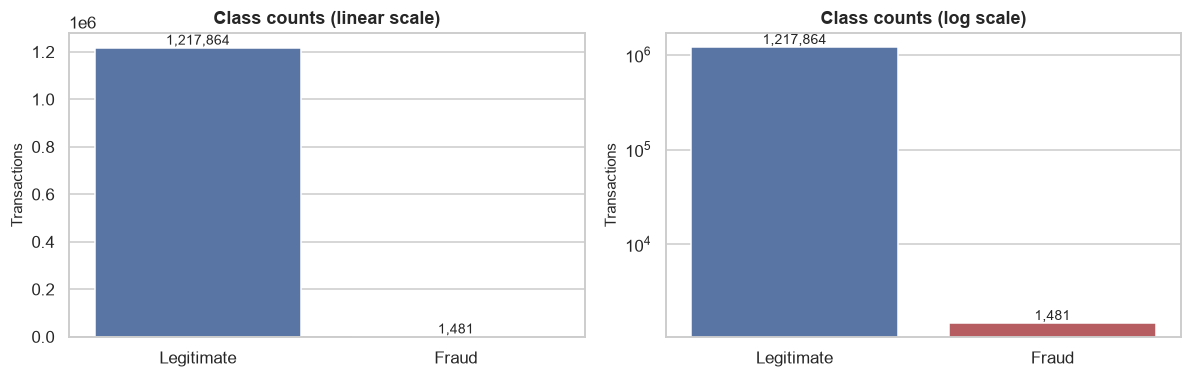

In [12]:
EXCLUDE_FROM_EDA = set(ACCOUNT_ID_COLUMNS + IDENTIFIER_COLUMNS + TEMPORAL_EXCLUDED_COLUMNS)

plot_df = pd.concat([
    df.loc[df[TARGET] == 1],
    df.loc[df[TARGET] == 0].sample(n=min(100_000, n_legit), random_state=RANDOM_STATE),
])
plot_df = plot_df.assign(Class=plot_df[TARGET].map({0: "Legitimate", 1: "Fraud"}))
class_palette = {"Legitimate": "#4C72B0", "Fraud": "#C44E52"}

eda_numeric = [c for c in numeric_cols_all if c not in EXCLUDE_FROM_EDA and df[c].nunique() > 10]
eda_categorical = [c for c in categorical_cols_all
                   if c not in EXCLUDE_FROM_EDA and df[c].nunique() <= MAX_CATEGORICAL_CARDINALITY]
print("Numeric columns used in EDA    :", eda_numeric)
print("Categorical columns used in EDA:", eda_categorical)

# ---------- Target distribution ----------
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, log_scale in zip(axes, (False, True)):
    sns.barplot(x=["Legitimate", "Fraud"], y=[n_legit, n_fraud], hue=["Legitimate", "Fraud"],
                palette=class_palette, legend=False, ax=ax)
    ax.set_yscale("log" if log_scale else "linear")
    ax.set_title("Class counts (log scale)" if log_scale else "Class counts (linear scale)")
    ax.set_ylabel("Transactions")
    for i, v in enumerate([n_legit, n_fraud]):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### Transaction amount

Amounts are heavy-tailed (and can be negative for refunds), so the signed-log transform `sign(x)·log1p(|x|)` is used for visual comparison.

Skewness of raw TransactionAmount: 4.94  (strongly right-skewed if >> 1)


,count,mean,std,min,5%,50%,95%,99%,max
IsFraud,,,,,,,,,
0,"1,217,864.0000",43.4948,81.5786,-500.0000,-51.0000,30.1700,146.2000,313.4937,"5,155.3600"
1,"1,481.0000",101.4398,170.0458,-485.0000,0.3400,66.4800,378.0000,652.5900,"2,052.7700"


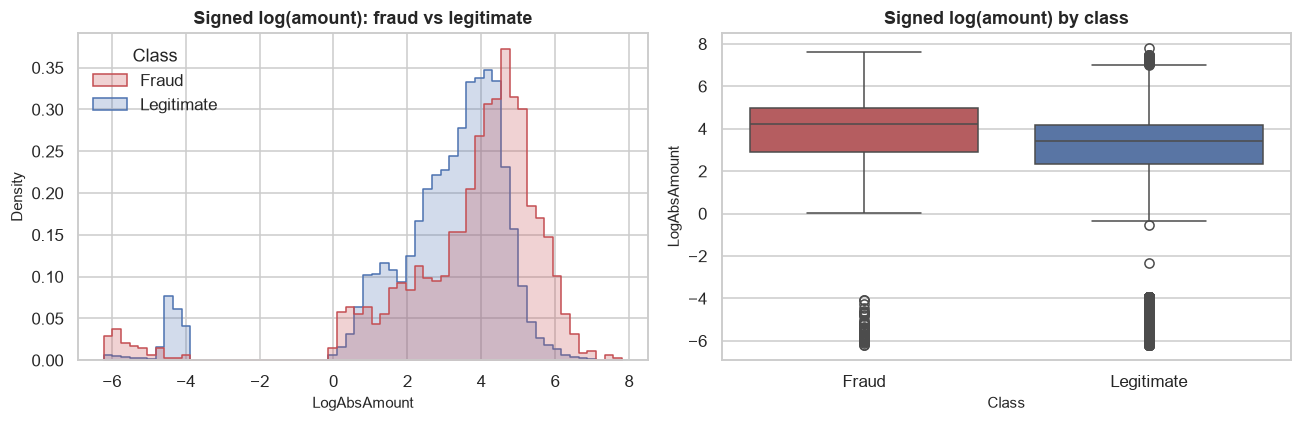

In [13]:
if "TransactionAmount" in df.columns:
    print(f"Skewness of raw TransactionAmount: {df['TransactionAmount'].skew():.2f}  "
          f"(strongly right-skewed if >> 1)")
    display(df.groupby(TARGET)["TransactionAmount"].describe(percentiles=[0.05, 0.5, 0.95, 0.99]))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data=plot_df, x="LogAbsAmount", hue="Class", stat="density", common_norm=False,
                 element="step", bins=60, palette=class_palette, ax=axes[0])
    axes[0].set_title("Signed log(amount): fraud vs legitimate")
    sns.boxplot(data=plot_df, x="Class", y="LogAbsAmount", hue="Class", palette=class_palette,
                legend=False, ax=axes[1])
    axes[1].set_title("Signed log(amount) by class")
    plt.tight_layout()
    plt.show()
else:
    print("TransactionAmount is not available - amount analysis skipped.")

### Fraud rate by transaction type and other categorical variables

The dashed line is the overall fraud rate. Categories with fewer than `min_count` transactions are hidden because their rates are too noisy to interpret.

Fraud rate by TransactionType:


,transactions,frauds,fraud_rate
TransactionType,,,
Online Transaction,135554,885,0.0065
Chip Transaction,314059,244,0.0008
Swipe Transaction,769732,352,0.0005


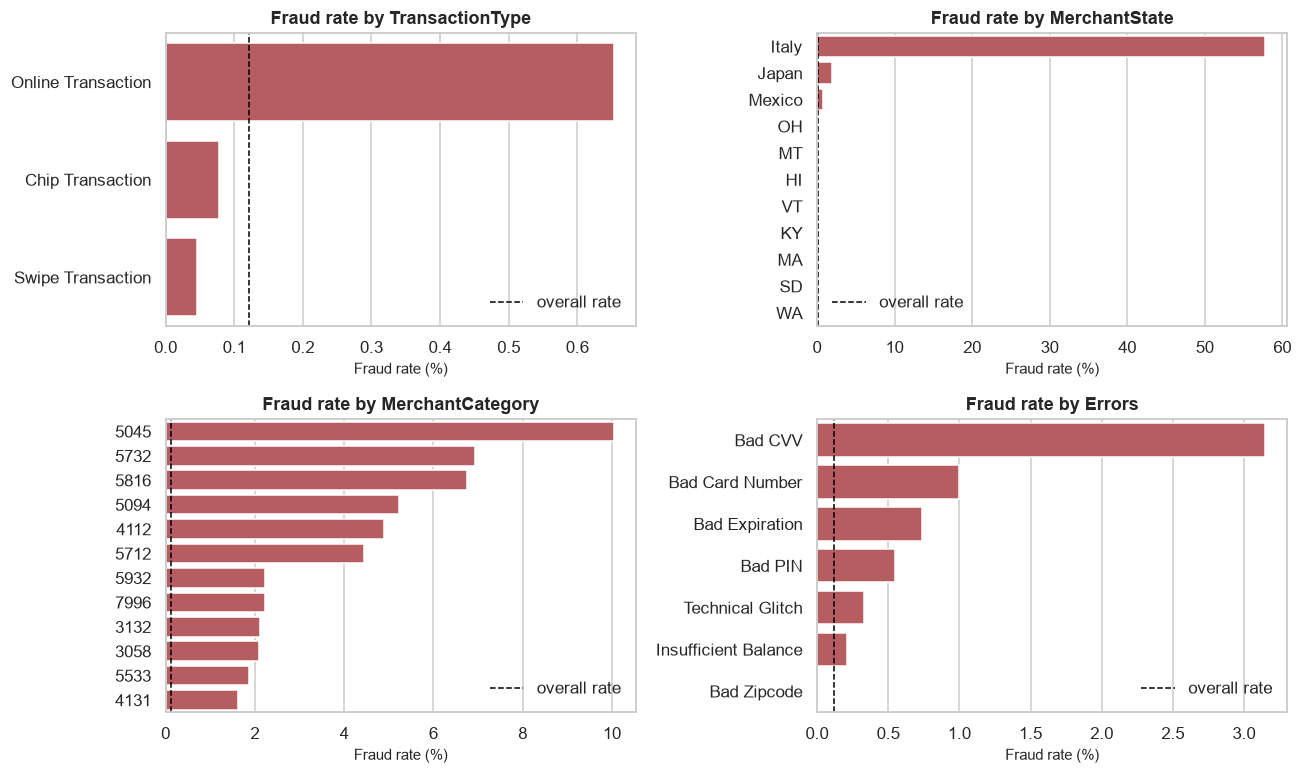

In [14]:
def fraud_rate_table(frame: pd.DataFrame, column: str, min_count: int = 100) -> pd.DataFrame:
    """Fraud rate per category with support counts; small categories are filtered out."""
    grouped = frame.groupby(column, dropna=False)[TARGET].agg(["size", "sum", "mean"])
    grouped.columns = ["transactions", "frauds", "fraud_rate"]
    grouped = grouped[grouped["transactions"] >= min_count]
    grouped.index = grouped.index.astype(str)
    return grouped.sort_values("fraud_rate", ascending=False)


def plot_fraud_rate(frame: pd.DataFrame, column: str, ax, top_n: int = 12, min_count: int = 100) -> None:
    table = fraud_rate_table(frame, column, min_count).head(top_n)
    if table.empty:
        ax.set_title(f"{column}: no category with >= {min_count} rows")
        return
    sns.barplot(x=table["fraud_rate"] * 100, y=table.index, color="#C44E52", ax=ax)
    ax.axvline(fraud_rate * 100, color="black", linestyle="--", linewidth=1, label="overall rate")
    ax.set_xlabel("Fraud rate (%)")
    ax.set_ylabel("")
    ax.set_title(f"Fraud rate by {column}")
    ax.legend()


if "TransactionType" in df.columns:
    print("Fraud rate by TransactionType:")
    display(fraud_rate_table(df, "TransactionType", min_count=1))

plot_cols = (["TransactionType"] if "TransactionType" in eda_categorical else []) + \
            [c for c in eda_categorical if c != "TransactionType"]
plot_cols = plot_cols[:6]
if plot_cols:
    n_cols = 2
    n_rows = int(np.ceil(len(plot_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.6 * n_rows), squeeze=False)
    for ax, col in zip(axes.ravel(), plot_cols):
        plot_fraud_rate(df, col, ax)
    for ax in axes.ravel()[len(plot_cols):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No suitable categorical columns for fraud-rate analysis.")

### Numerical distributions, time patterns and correlation

Values are clipped to the 1st–99th percentile *for plotting only*, so extreme (but legitimate) values do not flatten the picture.

**Correlation caveats.** The heatmap covers the raw numerical columns and the target only. One-hot encoded categoricals are deliberately excluded because dummy columns of one variable are mechanically correlated. Correlation measures linear association, **not causation**, and it can miss the non-linear and interaction effects that tree models exploit.

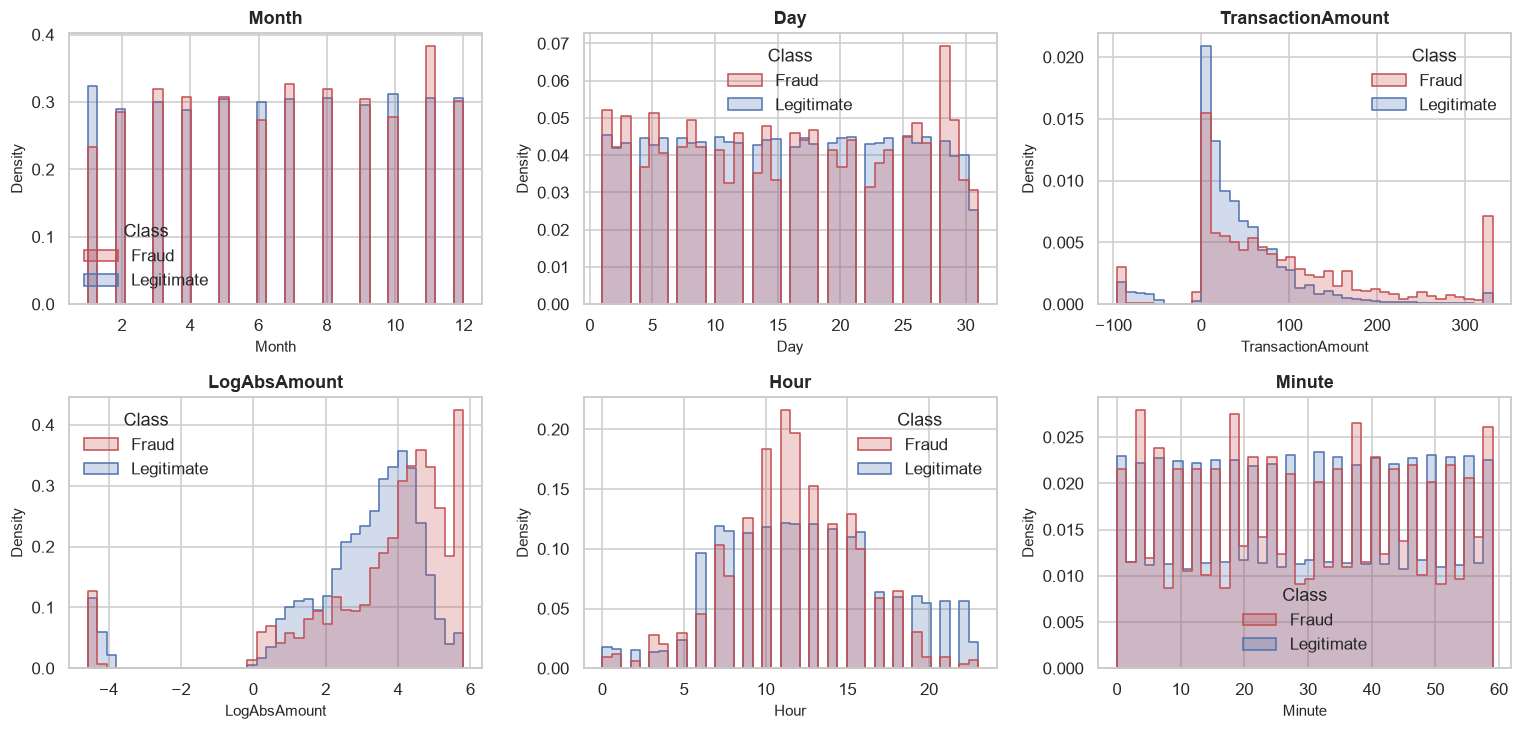

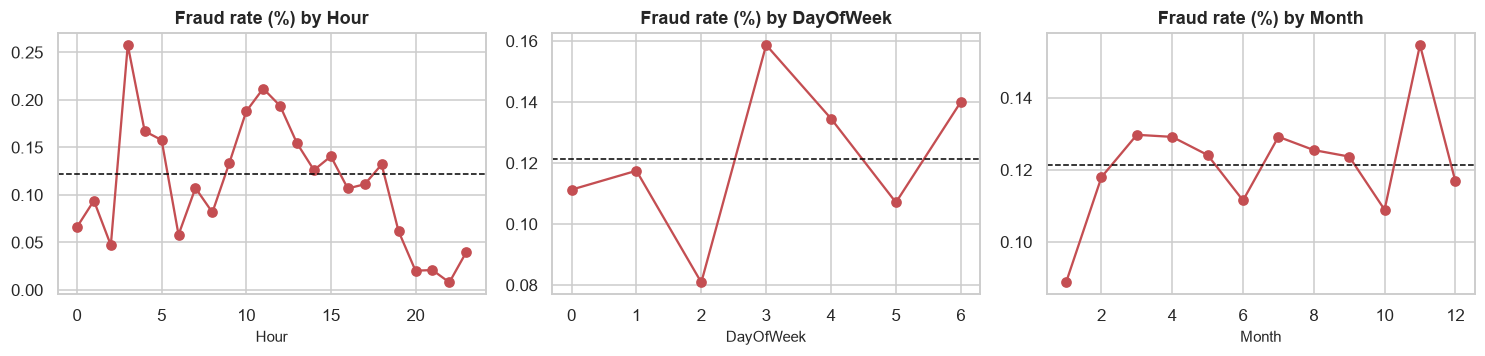

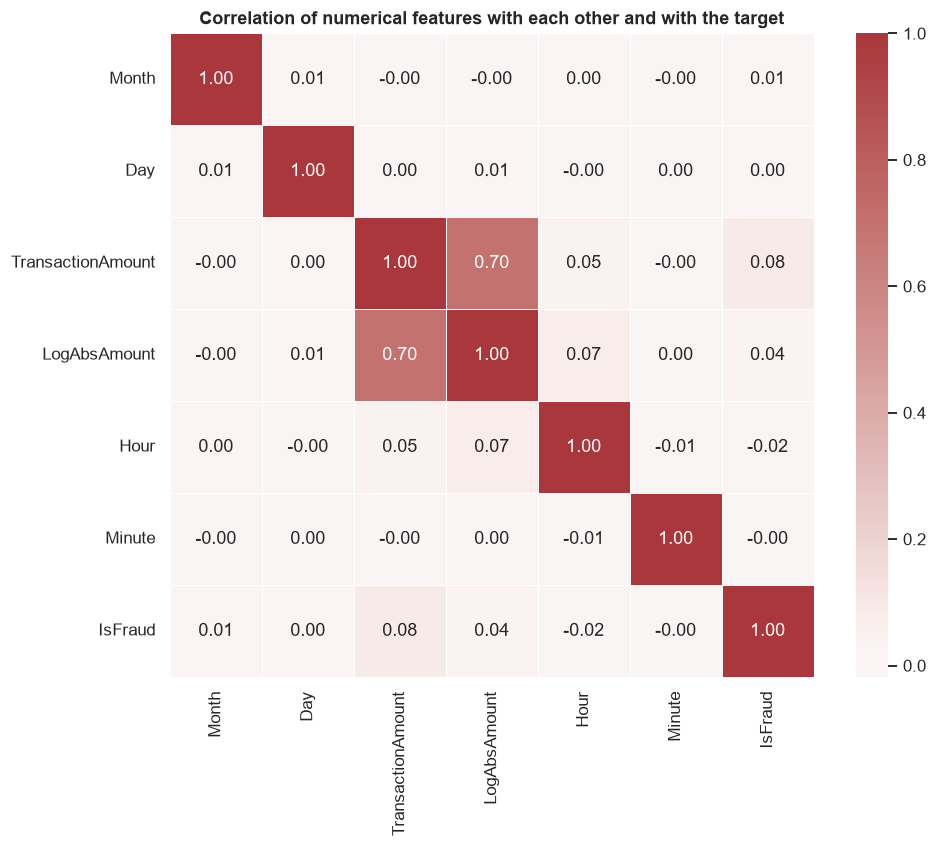

In [15]:
hist_cols = eda_numeric[:6]
if hist_cols:
    n_cols = 3
    n_rows = int(np.ceil(len(hist_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.4 * n_rows), squeeze=False)
    for ax, col in zip(axes.ravel(), hist_cols):
        lo, hi = plot_df[col].quantile([0.01, 0.99])
        sns.histplot(data=plot_df.assign(**{col: plot_df[col].clip(lo, hi)}), x=col, hue="Class",
                     stat="density", common_norm=False, element="step", bins=40,
                     palette=class_palette, ax=ax)
        ax.set_title(col)
    for ax in axes.ravel()[len(hist_cols):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

time_cols = [c for c in ("Hour", "DayOfWeek", "Month") if c in df.columns]
if time_cols:
    fig, axes = plt.subplots(1, len(time_cols), figsize=(4.6 * len(time_cols), 3.4), squeeze=False)
    for ax, col in zip(axes.ravel(), time_cols):
        rate = df.groupby(col)[TARGET].mean() * 100
        ax.plot(rate.index, rate.values, marker="o", color="#C44E52")
        ax.axhline(fraud_rate * 100, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"Fraud rate (%) by {col}")
        ax.set_xlabel(col)
    plt.tight_layout()
    plt.show()

corr_cols = eda_numeric + [TARGET]
if len(corr_cols) > 2:
    corr = plot_df[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(1.0 * len(corr_cols) + 3, 0.8 * len(corr_cols) + 2))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, linewidths=0.4, ax=ax)
    ax.set_title("Correlation of numerical features with each other and with the target")
    plt.show()

### Outliers

Extreme transaction values and balances are frequently *the signal* in fraud, so **outliers are not removed**. The table only quantifies how common they are and whether fraud is over-represented among them. `RobustScaler` (median/IQR based) is used later because it is far less distorted by heavy tails than mean/std scaling, so extreme values remain informative rather than dominating the scale.

In [16]:
outlier_rows = []
for col in [c for c in eda_numeric if df[c].nunique() > 50][:8]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        continue
    is_outlier = (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)
    outlier_rows.append({
        "feature": col,
        "outlier_pct": is_outlier.mean() * 100,
        "fraud_rate_outliers_pct": df.loc[is_outlier, TARGET].mean() * 100 if is_outlier.any() else np.nan,
        "fraud_rate_inliers_pct": df.loc[~is_outlier, TARGET].mean() * 100,
    })
display(pd.DataFrame(outlier_rows) if outlier_rows else "No continuous numeric features to assess.")

,feature,outlier_pct,fraud_rate_outliers_pct,fraud_rate_inliers_pct
0,TransactionAmount,7.7440,0.4204,0.0964
1,LogAbsAmount,5.1538,0.0875,0.1233
2,Minute,0.0000,NaN,0.1215


# 6. Data Leakage Analysis

Leakage silently inflates offline metrics and then collapses in production. Every item below is either **prevented by construction** or **checked**.

| Risk | How it is handled here |
|---|---|
| Imputation before the split | Imputers live inside the pipeline and are fitted on training data only |
| Scaling before the split | `RobustScaler` inside the pipeline, fitted on training data only |
| **SMOTE before the split** | SMOTE runs only inside `imblearn.pipeline.Pipeline`, after preprocessing, on training folds only |
| Test-set oversampling | Never. Resampling happens only in `fit`, never at predict/evaluation time |
| Target-derived variables | Univariate probe below flags features that are near-perfect predictors for review. Nothing is auto-dropped from label information |
| Future information | Only stateless, row-wise features are created before the split; no future-looking aggregates |
| Duplicates across train/test | Measured after the split |
| Post-investigation fields | Columns that may be populated *after* a fraud review (chargeback flags, case status, etc.) must be excluded on domain grounds. Review the `Errors` column and any similar field with the data owner |
| Account-level leakage | Account/card identifiers are excluded; overlap of accounts between train and test is measured |
| Temporal leakage | Chronological train/validation/future-test split prevents future observations from entering model selection |

**Aggregates warning.** Features like "customer's average spend" or "merchant fraud rate" are powerful but must be computed **only from data preceding each transaction**. Computing them over the whole dataset leaks future and label information.

**Hyperparameter and threshold leakage.** Tuning uses forward-in-time CV on the training core. The operating threshold is selected from forward-time out-of-fold development predictions. The future test set is used exactly once at the end.

In [17]:
def univariate_leakage_probe(frame: pd.DataFrame, target: str, exclude=(), max_categories: int = 300,
                             min_support: int = 50) -> pd.DataFrame:
    """Flag features that alone almost perfectly separate the classes (possible target proxies).

    Diagnostic only: results are for human review; nothing is dropped automatically.
    """
    y_values = frame[target].to_numpy()
    rows = []
    for col in frame.columns:
        if col == target or col in exclude or pd.api.types.is_datetime64_any_dtype(frame[col]):
            continue
        series = frame[col]
        if pd.api.types.is_numeric_dtype(series):
            filled = series.fillna(series.median())
            if filled.nunique() < 2:
                continue
            auc = roc_auc_score(y_values, filled)
            strength = max(auc, 1 - auc)
            rows.append({"feature": col, "kind": "numeric", "signal": strength,
                         "detail": f"univariate AUC={auc:.3f}", "review_flag": strength > 0.95})
        elif series.nunique() <= max_categories:
            grouped = frame.groupby(col, dropna=False)[target].agg(["size", "mean"])
            grouped = grouped[grouped["size"] >= min_support]
            if grouped.empty:
                continue
            top = grouped["mean"].idxmax()
            rows.append({"feature": col, "kind": "categorical", "signal": float(grouped["mean"].max()),
                         "detail": f"max category fraud rate={grouped['mean'].max():.3f} "
                                   f"('{top}', n={int(grouped.loc[top, 'size'])})",
                         "review_flag": grouped["mean"].max() > 0.5})
    return pd.DataFrame(rows).sort_values("signal", ascending=False) if rows else pd.DataFrame()


probe = univariate_leakage_probe(df, TARGET)
print("Univariate leakage probe (flag = numeric AUC > 0.95, or a supported category with fraud rate > 50%):")
display(probe)
if not probe.empty and probe["review_flag"].any():
    print("REVIEW REQUIRED:", probe.loc[probe["review_flag"], "feature"].tolist())
else:
    print("No feature is an implausibly strong single-column predictor.")

Univariate leakage probe (flag = numeric AUC > 0.95, or a supported category with fraud rate > 50%):


,feature,kind,signal,detail,review_flag
5,TransactionAmount,numeric,0.6473,univariate AUC=0.647,False
12,LogAbsAmount,numeric,0.6473,univariate AUC=0.647,False
8,MerchantState,categorical,0.5777,"max category fraud rate=0.578 ('Italy', n=431)",True
1,Card,numeric,0.5703,univariate AUC=0.570,False
7,MerchantName,numeric,0.5439,univariate AUC=0.544,False
13,Hour,numeric,0.5382,univariate AUC=0.462,False
15,DayOfWeek,numeric,0.5201,univariate AUC=0.520,False
3,Month,numeric,0.5143,univariate AUC=0.514,False
2,Year,numeric,0.5054,univariate AUC=0.495,False
4,Day,numeric,0.5053,univariate AUC=0.505,False


REVIEW REQUIRED: ['MerchantState']


# 7. Time-Aware Train / Validation / Test Split

Fraud detection is inherently temporal. The final test set therefore represents the **future**, not a random sample of the same time period.

- **Development training period:** earliest observations.
- **Validation period:** the next chronological block; used for model selection and diagnostics.
- **Future test period:** latest observations; kept untouched until final evaluation.

The training core used for tuning may be capped for runtime, but the cap is taken from the **latest portion of the training period**, not by random sampling across time.


In [18]:
# ---------- Primary chronological split ----------
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int).copy()

if "TransactionTimestamp" not in X.columns or X["TransactionTimestamp"].isna().all():
    raise ValueError("A usable TransactionTimestamp is required for the primary time-aware evaluation.")

order = X["TransactionTimestamp"].sort_values(kind="stable").index
X = X.loc[order].copy()
y = y.loc[order].copy()

n_total = len(X)
n_test = int(np.ceil(n_total * TEST_SIZE))
n_val = int(np.ceil(n_total * VAL_SIZE))

test_start = n_total - n_test
val_start = test_start - n_val
if val_start <= 0:
    raise ValueError("Dataset is too small for the configured chronological splits.")

X_train_full = X.iloc[:val_start].copy()
y_train_full = y.iloc[:val_start].copy()
X_val = X.iloc[val_start:test_start].copy()
y_val = y.iloc[val_start:test_start].copy()
X_test = X.iloc[test_start:].copy()
y_test = y.iloc[test_start:].copy()

# Runtime cap is applied only to the training core and keeps the rows contiguous in time.
if len(X_train_full) > MAX_TRAIN_ROWS:
    X_tr = X_train_full.iloc[-MAX_TRAIN_ROWS:].copy()
    y_tr = y_train_full.iloc[-MAX_TRAIN_ROWS:].copy()
    print(f"Training core capped to the latest {MAX_TRAIN_ROWS:,} rows of the development training period.")
else:
    X_tr = X_train_full.copy()
    y_tr = y_train_full.copy()

# Development data used for the final refit after model/threshold choices are frozen.
X_dev = pd.concat([X_train_full, X_val], axis=0)
y_dev = pd.concat([y_train_full, y_val], axis=0)


def class_distribution(name: str, target: pd.Series) -> dict:
    return {
        "partition": name,
        "rows": len(target),
        "legitimate": int((target == 0).sum()),
        "fraud": int((target == 1).sum()),
        "fraud_rate_%": target.mean() * 100,
        "time_min": X.loc[target.index, "TransactionTimestamp"].min(),
        "time_max": X.loc[target.index, "TransactionTimestamp"].max(),
    }

split_summary = pd.DataFrame([
    class_distribution("Training core used for fitting/CV", y_tr),
    class_distribution("Validation", y_val),
    class_distribution("Future test (untouched)", y_test),
])
display(split_summary)

for name, part in {"training core": y_tr, "validation": y_val, "future test": y_test}.items():
    if int(part.sum()) < 10:
        raise ValueError(
            f"Only {int(part.sum())} fraud cases are present in the {name} partition. "
            "Increase SAMPLE_FRACTION or use more source data."
        )

print(f"Chronological cut-offs: validation starts at {X_val['TransactionTimestamp'].min()} | "
      f"future test starts at {X_test['TransactionTimestamp'].min()}")


Training core capped to the latest 300,000 rows of the development training period.


,partition,rows,legitimate,fraud,fraud_rate_%,time_min,time_max
0,Training core used for fitting/CV,300000,299769,231,0.0770,2010-10-10 19:55:00,2014-06-28 16:55:00
1,Validation,243869,243518,351,0.1439,2014-06-28 16:56:00,2017-05-11 10:54:00
2,Future test (untouched),243869,243613,256,0.1050,2017-05-11 10:59:00,2020-02-28 23:05:00


Chronological cut-offs: validation starts at 2014-06-28 16:56:00 | future test starts at 2017-05-11 10:59:00


In [19]:
# ---------- Leakage diagnostics on the actual chronological split ----------
def row_hash(frame: pd.DataFrame) -> np.ndarray:
    """Stable per-row hash of all columns."""
    return pd.util.hash_pandas_object(frame, index=False).to_numpy()


duplicate_overlap = int(np.isin(row_hash(X_test), row_hash(X_dev)).sum())
print(f"Future-test rows whose full feature vector also appears in development: {duplicate_overlap:,} "
      f"({duplicate_overlap / len(X_test):.4%})")

for id_col in [c for c in ACCOUNT_ID_COLUMNS if c in X.columns]:
    seen = X_test[id_col].isin(set(X_dev[id_col])).mean()
    print(f"Future-test rows whose {id_col} also appears in development: {seen:.2%} "
          f"(identifier is excluded as a model feature)")

print("\nPrimary temporal coverage:")
display(pd.DataFrame({
    "development_min": [X_dev["TransactionTimestamp"].min()],
    "development_max": [X_dev["TransactionTimestamp"].max()],
    "validation_min": [X_val["TransactionTimestamp"].min()],
    "validation_max": [X_val["TransactionTimestamp"].max()],
    "test_min": [X_test["TransactionTimestamp"].min()],
    "test_max": [X_test["TransactionTimestamp"].max()],
}))


Future-test rows whose full feature vector also appears in development: 0 (0.0000%)
Future-test rows whose User also appears in development: 97.85% (identifier is excluded as a model feature)
Future-test rows whose Card also appears in development: 100.00% (identifier is excluded as a model feature)

Primary temporal coverage:


,development_min,development_max,validation_min,validation_max,test_min,test_max
0,1991-01-04 11:09:00,2017-05-11 10:54:00,2014-06-28 16:56:00,2017-05-11 10:54:00,2017-05-11 10:59:00,2020-02-28 23:05:00


# 8. Preprocessing Pipeline

Feature roles are assigned **dynamically from the training core only**, and every decision is reported (nothing is silently discarded):

* Account identifiers, near-unique identifiers and monotonic clocks → excluded.
* Constant or almost-entirely-missing columns → excluded.
* Numeric columns → `SimpleImputer(median)` → `RobustScaler`.
* Categoricals with low missingness → `SimpleImputer(most_frequent)` → `OneHotEncoder`.
* Categoricals with **high** missingness (> `HIGH_MISSING_THRESHOLD`) → constant `"__missing__"` level → `OneHotEncoder`. When most values are absent, the mode is a *real* value and imputing with it would corrupt the meaning ("no error" would be relabelled as some specific error); the missingness itself is informative.
* Categoricals with very high cardinality → excluded.

The `OneHotEncoder` pools rare categories (`min_frequency`) and uses `handle_unknown="infrequent_if_exist"`: unseen categories at prediction time never crash the pipeline (they map to the pooled level, or to all zeros if none exists), the same safety property as `"ignore"`.

In [20]:
def assign_feature_roles(X_ref: pd.DataFrame):
    """Decide each column's role from the training core only; return lists and a full audit table."""
    numeric, cat_low, cat_high, audit = [], [], [], []
    for col in X_ref.columns:
        s = X_ref[col]
        if col in ACCOUNT_ID_COLUMNS:
            role, reason = "excluded", "account/card identifier (memorisation risk)"
        elif col in IDENTIFIER_COLUMNS:
            role, reason = "excluded", "near-unique identifier"
        elif col in TEMPORAL_EXCLUDED_COLUMNS or pd.api.types.is_datetime64_any_dtype(s):
            role, reason = "excluded", "monotonic time (kept only for splitting)"
        elif s.nunique(dropna=True) <= 1:
            role, reason = "excluded", "constant column"
        elif s.isna().mean() > 0.99:
            role, reason = "excluded", ">99% missing"
        elif pd.api.types.is_numeric_dtype(s):
            role, reason = "numeric", ""
            numeric.append(col)
        elif s.nunique(dropna=True) > MAX_CATEGORICAL_CARDINALITY:
            role, reason = "excluded", f"cardinality {s.nunique():,} > {MAX_CATEGORICAL_CARDINALITY}"
        elif s.isna().mean() > HIGH_MISSING_THRESHOLD:
            role, reason = "categorical (high-missing)", f"{s.isna().mean():.1%} missing -> '__missing__' level"
            cat_high.append(col)
        else:
            role, reason = "categorical", ""
            cat_low.append(col)
        audit.append({"column": col, "role": role, "reason": reason})
    return numeric, cat_low, cat_high, pd.DataFrame(audit)


numeric_features, categorical_low_missing, categorical_high_missing, feature_audit = assign_feature_roles(X_tr)
categorical_features = categorical_low_missing + categorical_high_missing
feature_columns = numeric_features + categorical_features

display(feature_audit)
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
if not feature_columns:
    raise RuntimeError("No usable features remain after applying the feature policy.")

,column,role,reason
0,User,excluded,account/card identifier (memorisation risk)
1,Card,excluded,account/card identifier (memorisation risk)
2,Year,excluded,monotonic time (kept only for splitting)
3,Month,numeric,
4,Day,numeric,
5,TransactionAmount,numeric,
6,TransactionType,categorical,
7,MerchantName,excluded,near-unique identifier
8,MerchantCity,excluded,"cardinality 6,690 > 300"
9,MerchantState,categorical,


Numeric features (7): ['Month', 'Day', 'TransactionAmount', 'LogAbsAmount', 'Hour', 'Minute', 'DayOfWeek']
Categorical features (4): ['TransactionType', 'MerchantState', 'MerchantCategory', 'Errors']


In [21]:
def build_preprocessor(numeric, cat_low, cat_high) -> ColumnTransformer:
    """Unfitted preprocessing ColumnTransformer; fitted only when the surrounding pipeline is fitted."""
    def one_hot():
        return OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=MIN_CATEGORY_FREQUENCY,
                             sparse_output=False)

    transformers = []
    if numeric:
        transformers.append(("num", SklearnPipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]), numeric))
    if cat_low:
        transformers.append(("cat", SklearnPipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", one_hot()),
        ]), cat_low))
    if cat_high:
        transformers.append(("cat_hm", SklearnPipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
            ("onehot", one_hot()),
        ]), cat_high))
    return ColumnTransformer(transformers, remainder="drop", sparse_threshold=0.0)


def build_pipeline(model, use_smote: bool = False) -> Pipeline:
    """imblearn pipeline: preprocess -> (optional SMOTE, training folds only) -> model."""
    steps = [("preprocess", build_preprocessor(numeric_features, categorical_low_missing,
                                               categorical_high_missing))]
    if use_smote:
        steps.append(("smote", SMOTE(sampling_strategy=SMOTE_SAMPLING_STRATEGY, k_neighbors=5,
                                     random_state=RANDOM_STATE)))
    steps.append(("model", model))
    return Pipeline(steps)


# Fit on the training core only, just to show the transformed width.
demo_preprocessor = build_preprocessor(numeric_features, categorical_low_missing, categorical_high_missing)
demo_matrix = demo_preprocessor.fit_transform(X_tr)
print(f"Transformed training matrix: {demo_matrix.shape[0]:,} rows x {demo_matrix.shape[1]} columns "
      f"({len(numeric_features)} numeric + one-hot levels)")
del demo_preprocessor, demo_matrix

Transformed training matrix: 300,000 rows x 178 columns (7 numeric + one-hot levels)


# 9. Baseline Model

**Pipeline:** preprocessing → `LogisticRegression(class_weight="balanced")`.

Class weighting re-weights the loss so a missed fraud costs far more than a missed legitimate transaction, with no synthetic data. It is the simplest imbalance strategy and a strong baseline.

### Reusable evaluation utilities

`evaluate_model` reports precision, recall, F1, ROC-AUC, PR-AUC, the confusion counts and the false-positive/negative rates, at any threshold. Accuracy is deliberately **not** computed.

| Term | Meaning | Fraud interpretation |
|---|---|---|
| **TP** | fraud, flagged | fraud correctly caught |
| **FP** | legitimate, flagged | a good customer wrongly blocked or reviewed |
| **TN** | legitimate, not flagged | normal traffic passes |
| **FN** | fraud, not flagged | **fraud missed** — direct financial loss |

`FPR = FP / (FP + TN)`, `FNR = FN / (FN + TP) = 1 − recall`.

> Model selection and threshold choice use the **validation** set. Test-set results are deferred to the *Final Model Selection* section, so the test set can never influence a choice.

Fitted 'LogReg (balanced) - baseline' in 14.9s
--- LogReg (balanced) - baseline | threshold = 0.5000 ---
              precision    recall  f1-score   support

  Legitimate     0.9998    0.7698    0.8699    243518
       Fraud     0.0055    0.8889    0.0110       351

    accuracy                         0.7700    243869
   macro avg     0.5027    0.8294    0.4404    243869
weighted avg     0.9984    0.7700    0.8686    243869



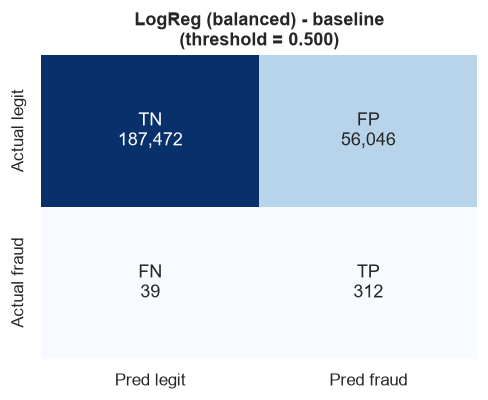

,Model,Threshold,Precision,Recall,F1,ROC_AUC,PR_AUC,TP,FP,TN,FN,FPR,FNR
0,LogReg (balanced) - baseline,0.5000,0.0055,0.8889,0.0110,0.9057,0.0224,312,56046,187472,39,0.2302,0.1111


In [22]:
def get_scores(model, X_eval: pd.DataFrame) -> np.ndarray:
    """Predicted fraud probability P(y=1) from any fitted pipeline."""
    return model.predict_proba(X_eval)[:, 1]


def plot_confusion(cm: np.ndarray, title: str, ax=None) -> None:
    """Labelled confusion matrix (rows = actual, columns = predicted)."""
    ax = ax or plt.subplots(figsize=(4.6, 3.8))[1]
    labels = np.array([[f"TN\n{cm[0, 0]:,}", f"FP\n{cm[0, 1]:,}"],
                       [f"FN\n{cm[1, 0]:,}", f"TP\n{cm[1, 1]:,}"]])
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred legit", "Pred fraud"], yticklabels=["Actual legit", "Actual fraud"])
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def evaluate_model(model, X_eval, y_eval, model_name: str, threshold: float = 0.5, y_proba=None,
                   show_report: bool = False, plot_cm: bool = False) -> dict:
    """Fraud-oriented evaluation at a given probability threshold. Returns a metrics dict."""
    y_true = np.asarray(y_eval).astype(int)
    if y_proba is None:
        y_proba = get_scores(model, X_eval)
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = (int(v) for v in cm.ravel())

    if show_report:
        print(f"--- {model_name} | threshold = {threshold:.4f} ---")
        print(classification_report(y_true, y_pred, target_names=["Legitimate", "Fraud"], digits=4,
                                    zero_division=0))
    if plot_cm:
        plot_confusion(cm, f"{model_name}\n(threshold = {threshold:.3f})")

    return {
        "Model": model_name,
        "Threshold": float(threshold),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_proba),
        "PR_AUC": average_precision_score(y_true, y_proba),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "FPR": fp / (fp + tn) if (fp + tn) else 0.0,
        "FNR": fn / (fn + tp) if (fn + tp) else 0.0,
    }


def fit_timed(name: str, pipeline: Pipeline) -> Pipeline:
    """Fit on the training core only and report wall-clock time."""
    start = time.perf_counter()
    pipeline.fit(X_tr, y_tr)
    print(f"Fitted '{name}' in {time.perf_counter() - start:,.1f}s")
    return pipeline


fitted_models, cv_scores = {}, {}
validation_results, val_proba = {}, {}


def register_validation(name: str, model, **eval_kwargs) -> dict:
    """Score a fitted model on the validation set once and cache probabilities + metrics."""
    val_proba[name] = get_scores(model, X_val)
    validation_results[name] = evaluate_model(model, X_val, y_val, name, y_proba=val_proba[name], **eval_kwargs)
    return validation_results[name]


BASELINE_NAME = "LogReg (balanced) - baseline"
fitted_models[BASELINE_NAME] = fit_timed(BASELINE_NAME, build_pipeline(
    LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
))
baseline_metrics = register_validation(BASELINE_NAME, fitted_models[BASELINE_NAME], show_report=True, plot_cm=True)
display(pd.DataFrame([baseline_metrics]))

# 10. Advanced Models and Imbalance Strategies

Three further candidates are compared against the baseline on the same validation data:

* **Random Forest** with `class_weight="balanced"` — a strong non-linear baseline for tabular data.
* **HistGradientBoosting** with `class_weight="balanced"` — usually the strongest scikit-learn option on tabular fraud data. The preprocessing emits a dense matrix, which it requires.
* **Logistic Regression + SMOTE** — synthetic minority oversampling *inside the pipeline*, after preprocessing, applied to training data only.

**SMOTE is not assumed to be better than class weighting.** It is one candidate judged by the same validation PR-AUC. Known limitations for transaction data:

* SMOTE interpolates between minority neighbours in feature space. After one-hot encoding, the interpolated dummy columns take **fractional values** (e.g. 0.4 "online" / 0.6 "swipe") that no real transaction can have. `SMOTENC` handles this better but needs the raw categorical layout.
* Fraud is often several distinct behaviours; interpolating between them can create unrealistic "in-between" points.
* It can blur the class boundary and worsen probability calibration, which matters when thresholds drive operations.
* It adds training cost and hyper-parameters (ratio, `k`).

In [23]:
RF_NAME = "RandomForest (balanced)"
HGB_NAME = "HistGradientBoosting (balanced)"
SMOTE_NAME = "LogReg + SMOTE"

fitted_models[RF_NAME] = fit_timed(RF_NAME, build_pipeline(RandomForestClassifier(
    n_estimators=150, min_samples_leaf=5, max_samples=0.5,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
)))
fitted_models[HGB_NAME] = fit_timed(HGB_NAME, build_pipeline(HistGradientBoostingClassifier(
    class_weight="balanced", max_iter=300, learning_rate=0.1, early_stopping=True, random_state=RANDOM_STATE,
)))

n_pos_tr = int(y_tr.sum())
if n_pos_tr >= 50:      # SMOTE needs enough minority neighbours in every training fold
    fitted_models[SMOTE_NAME] = fit_timed(SMOTE_NAME, build_pipeline(
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), use_smote=True))
else:
    print(f"Skipping SMOTE: only {n_pos_tr} fraud cases in the training core.")

for name in (RF_NAME, HGB_NAME, SMOTE_NAME):
    if name in fitted_models:
        register_validation(name, fitted_models[name])

strategy_view = pd.DataFrame(list(validation_results.values()))[["Model", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]]
print("Validation comparison at the default 0.5 threshold (thresholds are optimised later):")
display(strategy_view)

Fitted 'RandomForest (balanced)' in 19.8s
Fitted 'HistGradientBoosting (balanced)' in 14.2s
Fitted 'LogReg + SMOTE' in 8.6s
Validation comparison at the default 0.5 threshold (thresholds are optimised later):


,Model,Precision,Recall,F1,ROC_AUC,PR_AUC
0,LogReg (balanced) - baseline,0.0055,0.8889,0.0110,0.9057,0.0224
1,RandomForest (balanced),0.0298,0.8604,0.0577,0.9412,0.2141
2,HistGradientBoosting (balanced),0.0488,0.8291,0.0922,0.9408,0.2163
3,LogReg + SMOTE,0.0107,0.6895,0.0210,0.8893,0.0946


# 11. Hyperparameter Optimization

Tree models are tuned with forward-in-time CV. SMOTE is also tuned rather than compared only at a single arbitrary configuration.

The primary metric remains **Average Precision / PR-AUC**. Accuracy is intentionally not optimized.


In [24]:
# Time-series cross-validation on the training core
# Each validation fold occurs strictly after its corresponding training fold.
cv_folds = int(max(2, min(CV_FOLDS, max(2, len(X_tr) // 50_000))))
cv = TimeSeriesSplit(n_splits=cv_folds)
print(f"TimeSeriesSplit with {cv_folds} folds on {len(X_tr):,} chronologically ordered training rows "
      f"({int(y_tr.sum())} fraud cases)")


def run_grid_search(name: str, estimator: Pipeline, param_grid: dict) -> GridSearchCV:
    """Grid search optimising Average Precision using forward-in-time CV."""
    search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True,
        error_score="raise",
        return_train_score=True,
    )
    start = time.perf_counter()
    search.fit(X_tr, y_tr)
    elapsed = time.perf_counter() - start
    print(f"\n[{name}] search finished in {elapsed:,.1f}s")
    print(f"[{name}] best params          : {search.best_params_}")
    print(f"[{name}] best CV PR-AUC       : {search.best_score_:.4f}")
    cv_scores[name] = float(search.best_score_)
    display(
        pd.DataFrame(search.cv_results_)[
            ["params", "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"]
        ].sort_values("rank_test_score").head(8)
    )
    return search


TimeSeriesSplit with 4 folds on 300,000 chronologically ordered training rows (231 fraud cases)


In [25]:
RF_TUNED = "RandomForest (tuned)"
rf_param_grid = ({"model__max_depth": [12], "model__min_samples_leaf": [5]} if FAST_MODE else
                 {"model__max_depth": [12, 20], "model__min_samples_leaf": [2, 10]})
rf_search = run_grid_search(
    RF_TUNED,
    build_pipeline(RandomForestClassifier(
        n_estimators=150,
        max_samples=0.5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
    rf_param_grid,
)
fitted_models[RF_TUNED] = rf_search.best_estimator_.set_params(model__n_jobs=-1)
register_validation(RF_TUNED, fitted_models[RF_TUNED])


HGB_TUNED = "HistGradientBoosting (tuned)"
hgb_param_grid = ({"model__learning_rate": [0.1], "model__max_leaf_nodes": [31]} if FAST_MODE else
                  {"model__learning_rate": [0.05, 0.1], "model__max_leaf_nodes": [15, 31, 63]})
hgb_search = run_grid_search(
    HGB_TUNED,
    build_pipeline(HistGradientBoostingClassifier(
        class_weight="balanced",
        max_iter=300,
        l2_regularization=1.0,
        early_stopping=True,
        random_state=RANDOM_STATE,
    )),
    hgb_param_grid,
)
fitted_models[HGB_TUNED] = hgb_search.best_estimator_
register_validation(HGB_TUNED, fitted_models[HGB_TUNED])


SMOTE_TUNED = "LogReg + SMOTE (tuned)"
smote_param_grid = ({
    "smote__sampling_strategy": [0.05],
    "smote__k_neighbors": [2],
} if FAST_MODE else {
    "smote__sampling_strategy": [0.02, 0.05, 0.10],
    "smote__k_neighbors": [3, 5],
})
smote_search = run_grid_search(
    SMOTE_TUNED,
    build_pipeline(
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        use_smote=True,
    ),
    smote_param_grid,
)
fitted_models[SMOTE_TUNED] = smote_search.best_estimator_
register_validation(SMOTE_TUNED, fitted_models[SMOTE_TUNED])

print("\nCross-validated PR-AUC by tuned candidate:")
display(pd.Series(cv_scores, name="CV_PR_AUC").sort_values(ascending=False).to_frame())


Fitting 4 folds for each of 4 candidates, totalling 16 fits

[RandomForest (tuned)] search finished in 246.1s
[RandomForest (tuned)] best params          : {'model__max_depth': 20, 'model__min_samples_leaf': 2}
[RandomForest (tuned)] best CV PR-AUC       : 0.1775


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
2,"{'model__max_depth': 20, 'model__min_samples_l...",0.9891,0.1775,0.1635,1
0,"{'model__max_depth': 12, 'model__min_samples_l...",0.8445,0.1264,0.1180,2
3,"{'model__max_depth': 20, 'model__min_samples_l...",0.8583,0.1087,0.1029,3
1,"{'model__max_depth': 12, 'model__min_samples_l...",0.7002,0.0990,0.0943,4


Fitting 4 folds for each of 6 candidates, totalling 24 fits

[HistGradientBoosting (tuned)] search finished in 125.9s
[HistGradientBoosting (tuned)] best params          : {'model__learning_rate': 0.1, 'model__max_leaf_nodes': 63}
[HistGradientBoosting (tuned)] best CV PR-AUC       : 0.1701


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
5,"{'model__learning_rate': 0.1, 'model__max_leaf...",0.3533,0.1701,0.0961,1
2,"{'model__learning_rate': 0.05, 'model__max_lea...",0.3463,0.1701,0.0959,2
4,"{'model__learning_rate': 0.1, 'model__max_leaf...",0.3210,0.1299,0.1056,3
1,"{'model__learning_rate': 0.05, 'model__max_lea...",0.2477,0.0879,0.0626,4
3,"{'model__learning_rate': 0.1, 'model__max_leaf...",0.0825,0.0443,0.0444,5
0,"{'model__learning_rate': 0.05, 'model__max_lea...",0.0711,0.0382,0.0328,6


Fitting 4 folds for each of 6 candidates, totalling 24 fits

[LogReg + SMOTE (tuned)] search finished in 61.3s
[LogReg + SMOTE (tuned)] best params          : {'smote__k_neighbors': 5, 'smote__sampling_strategy': 0.02}
[LogReg + SMOTE (tuned)] best CV PR-AUC       : 0.2142


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
3,"{'smote__k_neighbors': 5, 'smote__sampling_str...",0.4851,0.2142,0.1357,1
0,"{'smote__k_neighbors': 3, 'smote__sampling_str...",0.4773,0.1988,0.1262,2
4,"{'smote__k_neighbors': 5, 'smote__sampling_str...",0.4150,0.1762,0.1252,3
1,"{'smote__k_neighbors': 3, 'smote__sampling_str...",0.3690,0.1334,0.0833,4
5,"{'smote__k_neighbors': 5, 'smote__sampling_str...",0.3495,0.1260,0.0773,5
2,"{'smote__k_neighbors': 3, 'smote__sampling_str...",0.3405,0.1124,0.0721,6



Cross-validated PR-AUC by tuned candidate:


,CV_PR_AUC
LogReg + SMOTE (tuned),0.2142
RandomForest (tuned),0.1775
HistGradientBoosting (tuned),0.1701


# 12. Model Evaluation

All candidates are evaluated on the **chronological validation period**. The provisional champion is selected using validation PR-AUC only.

The future test set remains untouched until the final evaluation section.


,Model,Precision,Recall,F1,ROC_AUC,PR_AUC,TP,FP,TN,FN,FPR,FNR
0,LogReg (balanced) - baseline,0.0055,0.8889,0.0110,0.9057,0.0224,312,56046,187472,39,0.2302,0.1111
1,RandomForest (balanced),0.0298,0.8604,0.0577,0.9412,0.2141,302,9823,233695,49,0.0403,0.1396
2,HistGradientBoosting (balanced),0.0488,0.8291,0.0922,0.9408,0.2163,291,5667,237851,60,0.0233,0.1709
3,LogReg + SMOTE,0.0107,0.6895,0.0210,0.8893,0.0946,242,22425,221093,109,0.0921,0.3105
4,RandomForest (tuned),0.0444,0.8063,0.0842,0.9406,0.2350,283,6090,237428,68,0.0250,0.1937
5,HistGradientBoosting (tuned),0.0972,0.7151,0.1712,0.9466,0.2350,251,2331,241187,100,0.0096,0.2849
6,LogReg + SMOTE (tuned),0.0175,0.5641,0.0339,0.8811,0.1058,198,11133,232385,153,0.0457,0.4359



Provisional champion (highest validation PR-AUC): HistGradientBoosting (tuned)
--- HistGradientBoosting (tuned) | threshold = 0.5000 ---
              precision    recall  f1-score   support

  Legitimate     0.9996    0.9904    0.9950    243518
       Fraud     0.0972    0.7151    0.1712       351

    accuracy                         0.9900    243869
   macro avg     0.5484    0.8528    0.5831    243869
weighted avg     0.9983    0.9900    0.9938    243869



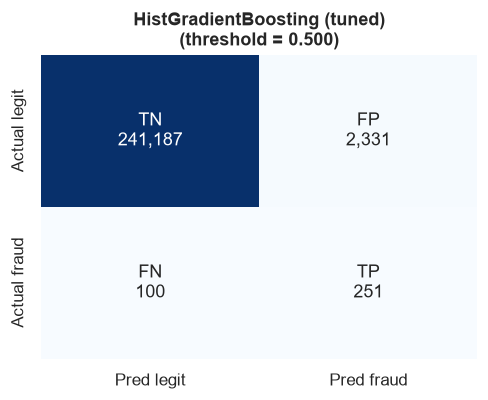

In [26]:
comparison = pd.DataFrame(list(validation_results.values()))
display(comparison[["Model", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC", "TP", "FP", "TN", "FN", "FPR", "FNR"]])

champion_name = comparison.sort_values("PR_AUC", ascending=False).iloc[0]["Model"]
print(f"\nProvisional champion (highest validation PR-AUC): {champion_name}")

champion_model = fitted_models[champion_name]
_ = evaluate_model(champion_model, X_val, y_val, champion_name, 0.5,
                   y_proba=val_proba[champion_name], show_report=True, plot_cm=True)

# 13. Precision-Recall and ROC Analysis

Both curves are drawn for every model on the validation set. **PR curves are usually more informative than ROC curves when the positive class is extremely rare:** ROC curves are insensitive to class imbalance, so a model can show an excellent ROC-AUC while most of its alerts are false. The PR curve shows the precision you actually pay for each level of recall, and its no-skill baseline is the fraud rate (the dashed horizontal line) rather than 0.5.

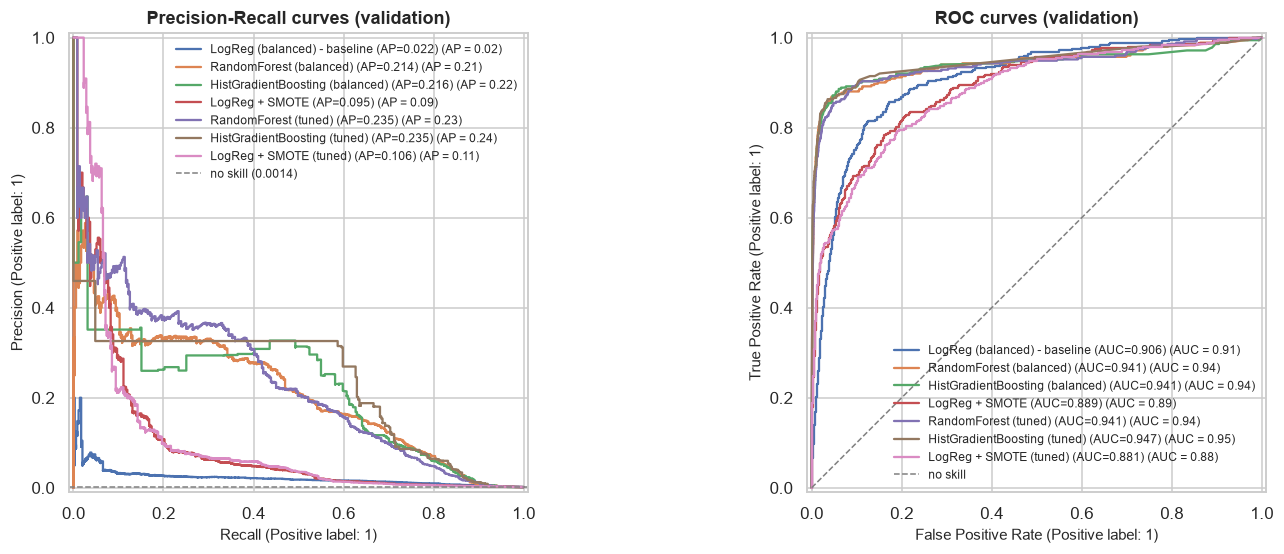

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
val_prevalence = float(np.mean(y_val))
for name, proba in val_proba.items():
    PrecisionRecallDisplay.from_predictions(y_val, proba, name=f"{name} (AP={validation_results[name]['PR_AUC']:.3f})",
                                            ax=axes[0])
    RocCurveDisplay.from_predictions(y_val, proba, name=f"{name} (AUC={validation_results[name]['ROC_AUC']:.3f})",
                                     ax=axes[1])
axes[0].axhline(val_prevalence, color="grey", linestyle="--", linewidth=1, label=f"no skill ({val_prevalence:.4f})")
axes[0].set_title("Precision-Recall curves (validation)")
axes[0].legend(fontsize=8, loc="upper right")
axes[1].plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1, label="no skill")
axes[1].set_title("ROC curves (validation)")
axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

# 14. Threshold Optimization and Business Cost

The operating threshold is selected **after model selection** and without using the final future test set.

This version uses out-of-fold probabilities across the development period with forward-in-time folds. That reduces dependence on one validation partition and keeps threshold selection separate from the final fit.

The cost model is deliberately illustrative: replace it with organization-specific fraud-loss, chargeback, customer-friction and review-capacity estimates before operational use.


In [28]:
def candidate_thresholds(y_true, y_proba, max_points: int = 400) -> np.ndarray:
    """Threshold grid: regular values plus data-driven PR-curve thresholds."""
    _, _, pr_thresholds = precision_recall_curve(y_true, y_proba)
    if len(pr_thresholds) > max_points:
        pr_thresholds = np.quantile(pr_thresholds, np.linspace(0, 1, max_points))
    return np.unique(np.concatenate([np.linspace(0.01, 0.99, 99), pr_thresholds]))


def threshold_table(y_true, y_proba, thresholds, cost_fn: float, cost_fp: float) -> pd.DataFrame:
    """Precision / recall / F1 / FP / FN / alert rate / assumed cost for each threshold."""
    y_true = np.asarray(y_true).astype(int)
    actual_fraud = y_true == 1
    rows = []
    for t in thresholds:
        flagged = y_proba >= t
        tp = int((flagged & actual_fraud).sum())
        fp = int((flagged & ~actual_fraud).sum())
        fn = int((~flagged & actual_fraud).sum())
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        rows.append({
            "threshold": float(t),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "false_positives": fp,
            "false_negatives": fn,
            "alerts": tp + fp,
            "alert_rate_%": 100 * (tp + fp) / len(y_true),
            "total_cost": fn * cost_fn + fp * cost_fp,
        })
    return pd.DataFrame(rows)


def best_for_recall_target(table: pd.DataFrame, target_recall: float):
    eligible = table[table["recall"] >= target_recall]
    if eligible.empty:
        return None
    return eligible.sort_values(["precision", "threshold"], ascending=[False, False]).iloc[0]


def select_threshold(table: pd.DataFrame, strategy: str, target_recall: float):
    if strategy == "recall_target":
        row = best_for_recall_target(table, target_recall)
        if row is not None:
            return float(row["threshold"]), f"highest-precision threshold with OOF recall >= {target_recall:.0%}"
        print(f"No threshold reaches recall >= {target_recall:.0%}; falling back to max-F1.")
        strategy = "max_f1"
    if strategy == "min_cost":
        row = table.loc[table["total_cost"].idxmin()]
        return float(row["threshold"]), "minimum total cost under the ASSUMED cost values"
    if strategy == "max_f1":
        row = table.loc[table["f1"].idxmax()]
        return float(row["threshold"]), "maximum F1 on out-of-fold development predictions"
    raise ValueError(f"Unknown THRESHOLD_STRATEGY: {strategy}")


def forward_oof_probabilities(estimator, X_data: pd.DataFrame, y_data: pd.Series, n_splits: int = 4):
    """Generate forward-in-time OOF probabilities for threshold selection."""
    splitter = TimeSeriesSplit(n_splits=n_splits)
    oof = np.full(len(X_data), np.nan, dtype=float)
    fold_rows = []

    for fold, (fit_idx, score_idx) in enumerate(splitter.split(X_data), start=1):
        fold_model = clone(estimator)
        fold_model.fit(X_data.iloc[fit_idx], y_data.iloc[fit_idx])
        fold_proba = fold_model.predict_proba(X_data.iloc[score_idx])[:, 1]
        oof[score_idx] = fold_proba
        fold_rows.append({
            "fold": fold,
            "fit_rows": len(fit_idx),
            "score_rows": len(score_idx),
            "score_fraud": int(y_data.iloc[score_idx].sum()),
        })

    valid = np.isfinite(oof)
    return oof[valid], y_data.iloc[np.flatnonzero(valid)], pd.DataFrame(fold_rows)


In [29]:
# ---------- Forward OOF probabilities for threshold selection ----------
champion_model_for_threshold = clone(champion_model)
oof_proba, y_oof, oof_fold_summary = forward_oof_probabilities(
    champion_model_for_threshold,
    X_dev,
    y_dev,
    n_splits=OOF_FOLDS,
)

display(oof_fold_summary)
print(f"OOF coverage: {len(y_oof):,} / {len(y_dev):,} development rows")
print(f"OOF fraud cases: {int(y_oof.sum()):,}")

thresholds = candidate_thresholds(y_oof, oof_proba)
threshold_df = threshold_table(
    y_oof,
    oof_proba,
    thresholds,
    COST_FALSE_NEGATIVE,
    COST_FALSE_POSITIVE,
)

f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
print(f"Maximum OOF F1 = {f1_row['f1']:.4f} at threshold {f1_row['threshold']:.4f}")


,fold,fit_rows,score_rows,score_fraud
0,1,195096,195095,359
1,2,390191,195095,201
2,3,585286,195095,141
3,4,780381,195095,351


OOF coverage: 780,380 / 975,476 development rows
OOF fraud cases: 1,052
Maximum OOF F1 = 0.2521 at threshold 0.9600


### Cost-based view

Total cost = `FN x COST_FALSE_NEGATIVE + FP x COST_FALSE_POSITIVE`.

> **The cost values in the configuration cell are illustrative assumptions in relative units, not real monetary figures.** Replace them with estimates from your organisation (fraud loss and chargeback cost vs. review and customer-friction cost), and check the resulting alert volume against manual-review capacity, before using any threshold operationally.

In [30]:
best_cost_row = threshold_df.loc[threshold_df["total_cost"].idxmin()]
f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
default_row = threshold_table(y_oof, oof_proba, [0.5], COST_FALSE_NEGATIVE, COST_FALSE_POSITIVE).iloc[0]

recall_row = best_for_recall_target(threshold_df, TARGET_RECALL)
policies = {
    "default 0.5": default_row,
    "max F1": f1_row,
    "min assumed cost": best_cost_row,
}
if recall_row is not None:
    policies[f"recall >= {TARGET_RECALL:.0%}"] = recall_row

policy_table = pd.DataFrame(policies).T[[
    "threshold", "precision", "recall", "f1",
    "false_positives", "false_negatives", "alert_rate_%", "total_cost"
]]
print(f"Policy comparison on OOF development predictions (ASSUMED costs: FN={COST_FALSE_NEGATIVE}, FP={COST_FALSE_POSITIVE}):")
display(policy_table)

selected_threshold, threshold_note = select_threshold(
    threshold_df,
    THRESHOLD_STRATEGY,
    TARGET_RECALL,
)
print(f"Selected operating threshold: {selected_threshold:.4f} ({threshold_note})")


Policy comparison on OOF development predictions (ASSUMED costs: FN=100.0, FP=1.0):


,threshold,precision,recall,f1,false_positives,false_negatives,alert_rate_%,total_cost
default 0.5,0.5000,0.0296,0.6321,0.0566,"21,797.0000",387.0000,2.8783,"60,497.0000"
max F1,0.9600,0.1920,0.3669,0.2521,"1,624.0000",666.0000,0.2576,"68,224.0000"
min assumed cost,0.7800,0.0623,0.5703,0.1124,"9,026.0000",452.0000,1.2335,"54,226.0000"
recall >= 90%,0.0250,0.0023,0.9002,0.0047,"404,619.0000",105.0000,51.9703,"415,119.0000"


Selected operating threshold: 0.9600 (maximum F1 on out-of-fold development predictions)


# 15. Model Interpretation

* **Logistic Regression** coefficients act on scaled features: positive values push towards fraud, negative values away from it (for one-hot columns, relative to the other levels).
* **Random Forest** impurity importances show how much a feature is used for splitting. They are biased towards high-cardinality features.
* **Permutation importance** (on validation, for the champion) is model-agnostic: it measures the drop in PR-AUC when a raw input column is shuffled.

Transformed feature names come from `get_feature_names_out()`, and lengths are asserted so names always align with the coefficients.

> Importance and coefficients describe **associations the model uses, not causes**. Correlated features share credit, and the synthetic or sampled nature of the data may make some patterns unrepresentative of real fraud.

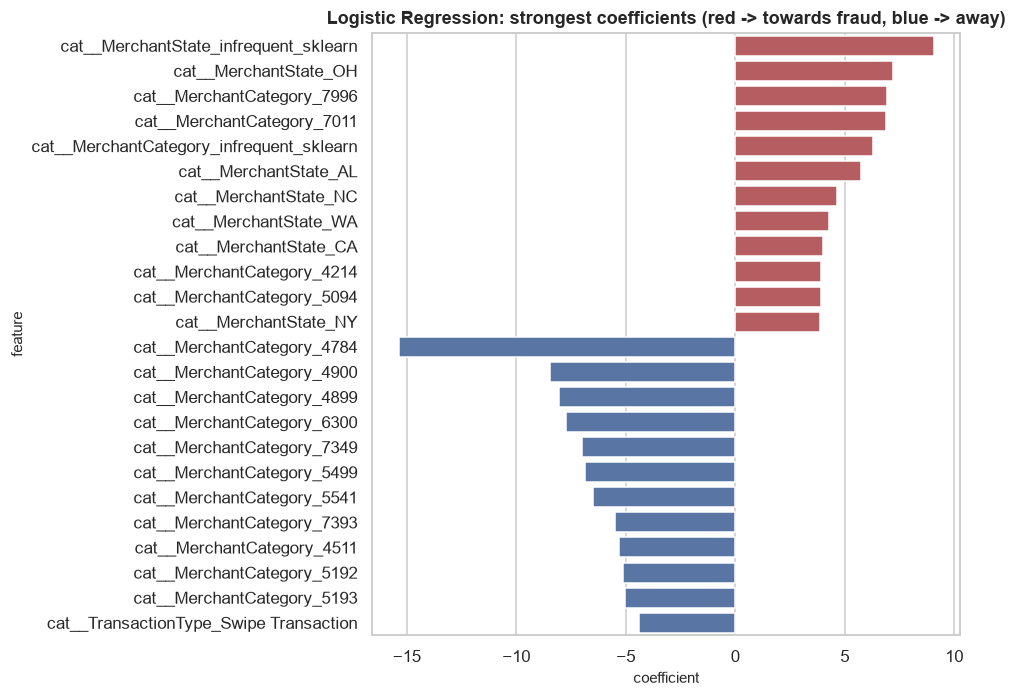

In [31]:
def transformed_feature_names(fitted_pipeline: Pipeline) -> np.ndarray:
    return fitted_pipeline.named_steps["preprocess"].get_feature_names_out()


# ---------- Logistic Regression coefficients ----------
lr_pipeline = fitted_models[BASELINE_NAME]
lr_names = transformed_feature_names(lr_pipeline)
lr_coefs = lr_pipeline.named_steps["model"].coef_.ravel()
assert len(lr_names) == len(lr_coefs), "Feature names and coefficients are misaligned."

coef_df = pd.DataFrame({"feature": lr_names, "coefficient": lr_coefs})
top_coefs = pd.concat([coef_df.nlargest(12, "coefficient"), coef_df.nsmallest(12, "coefficient")])
fig, ax = plt.subplots(figsize=(9, 6.5))
sns.barplot(data=top_coefs, x="coefficient", y="feature", hue=top_coefs["coefficient"] > 0,
            palette={True: "#C44E52", False: "#4C72B0"}, legend=False, ax=ax)
ax.set_title("Logistic Regression: strongest coefficients (red -> towards fraud, blue -> away)")
plt.tight_layout()
plt.show()

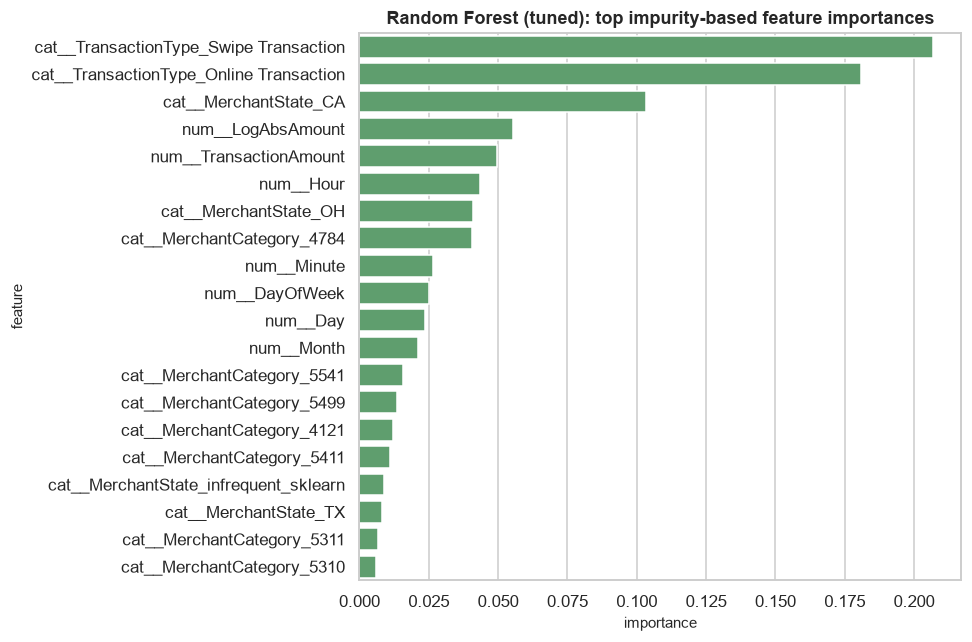

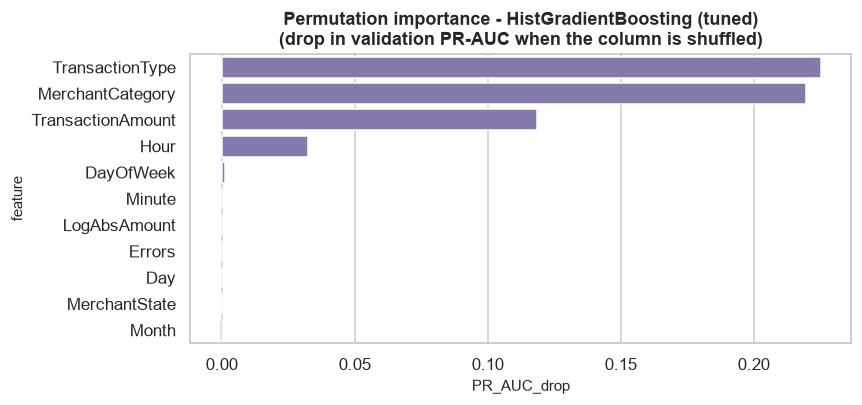

,feature,PR_AUC_drop,std
7,TransactionType,0.2254,0.0033
9,MerchantCategory,0.2195,0.0002
2,TransactionAmount,0.1185,0.0027
4,Hour,0.0325,0.0170
6,DayOfWeek,0.0013,0.0020
5,Minute,0.0002,0.0002
3,LogAbsAmount,0.0000,0.0000
10,Errors,0.0000,0.0000
1,Day,-0.0001,0.0005
8,MerchantState,-0.0002,0.0006


In [32]:
# ---------- Random Forest importances ----------
rf_pipeline = fitted_models[RF_TUNED]
rf_names = transformed_feature_names(rf_pipeline)
rf_importances = rf_pipeline.named_steps["model"].feature_importances_
assert len(rf_names) == len(rf_importances), "Feature names and importances are misaligned."

rf_imp_df = pd.DataFrame({"feature": rf_names, "importance": rf_importances}).nlargest(20, "importance")
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=rf_imp_df, x="importance", y="feature", color="#55A868", ax=ax)
ax.set_title("Random Forest (tuned): top impurity-based feature importances")
plt.tight_layout()
plt.show()

# ---------- Permutation importance of the champion on raw inputs (validation) ----------
if len(X_val) > PERMUTATION_MAX_ROWS:
    X_perm, _, y_perm, _ = train_test_split(X_val, y_val, train_size=PERMUTATION_MAX_ROWS,
                                            stratify=y_val, random_state=RANDOM_STATE)
else:
    X_perm, y_perm = X_val, y_val
perm = permutation_importance(champion_model, X_perm[feature_columns], y_perm, scoring="average_precision",
                              n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1)
perm_df = pd.DataFrame({"feature": feature_columns, "PR_AUC_drop": perm.importances_mean,
                        "std": perm.importances_std}).sort_values("PR_AUC_drop", ascending=False)
fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(perm_df))))
sns.barplot(data=perm_df, x="PR_AUC_drop", y="feature", color="#8172B3", ax=ax)
ax.set_title(f"Permutation importance - {champion_name}\n(drop in validation PR-AUC when the column is shuffled)")
plt.tight_layout()
plt.show()
display(perm_df.head(10))

# 16. Final Model Refit and Future-Test Evaluation

The model choice and operating threshold are now frozen. The selected estimator is refit on **all pre-test development data** (`training + validation`).

Only after that refit is the **future test period** scored once.


Refitting final model 'HistGradientBoosting (tuned)' on 975,476 pre-test development rows...
--- HistGradientBoosting (tuned) | threshold = 0.9600 ---
              precision    recall  f1-score   support

  Legitimate     0.9990    0.9977    0.9983    243613
       Fraud     0.0070    0.0156    0.0097       256

    accuracy                         0.9966    243869
   macro avg     0.5030    0.5067    0.5040    243869
weighted avg     0.9979    0.9966    0.9973    243869



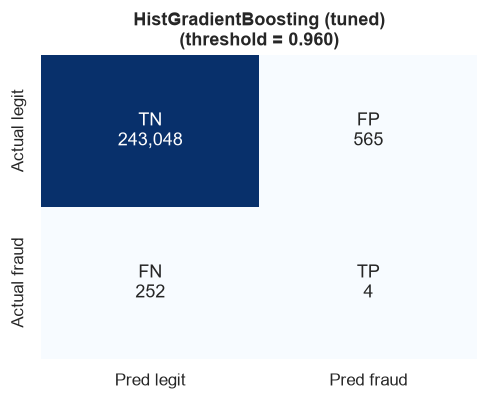

FINAL FUTURE-TEST RESULTS (single evaluation):


,Model,Threshold,Precision,Recall,F1,ROC_AUC,PR_AUC,TP,FP,TN,FN,FPR,FNR
0,HistGradientBoosting (tuned),0.9600,0.0070,0.0156,0.0097,0.7846,0.0087,4,565,243048,252,0.0023,0.9844
1,HistGradientBoosting (tuned) @ 0.5,0.5000,0.0063,0.1562,0.0121,0.7846,0.0087,40,6330,237283,216,0.0260,0.8438


No-skill PR-AUC on the future test equals its fraud rate: 0.1050%


In [33]:
final_model_name = champion_name
final_model = clone(fitted_models[final_model_name])

print(f"Refitting final model '{final_model_name}' on {len(X_dev):,} pre-test development rows...")
final_model.fit(X_dev, y_dev)

# One untouched future-test evaluation.
test_proba = get_scores(final_model, X_test)
test_metrics = evaluate_model(
    final_model,
    X_test,
    y_test,
    final_model_name,
    selected_threshold,
    y_proba=test_proba,
    show_report=True,
    plot_cm=True,
)

test_metrics_default = evaluate_model(
    final_model,
    X_test,
    y_test,
    f"{final_model_name} @ 0.5",
    0.5,
    y_proba=test_proba,
)

print("FINAL FUTURE-TEST RESULTS (single evaluation):")
display(pd.DataFrame([test_metrics, test_metrics_default])[
    ["Model", "Threshold", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC", "TP", "FP", "TN", "FN", "FPR", "FNR"]
])
print(f"No-skill PR-AUC on the future test equals its fraud rate: {float(np.mean(y_test)):.4%}")


# 17. Production Prediction Function

`predict_transaction()` accepts either the notebook's prepared schema or the **raw Kaggle transaction schema**. Raw records are canonicalized and feature-engineered before the fitted model sees them.

For deployment, move these preparation utilities into a versioned `src/` package alongside the model artifact so training and inference use exactly the same code.


In [34]:
def prepare_inference_frame(transaction) -> pd.DataFrame:
    """Canonicalize a raw or prepared single transaction using the same stateless feature preparation."""
    frame = pd.DataFrame([transaction]) if isinstance(transaction, dict) else transaction.copy()
    if len(frame) != 1:
        raise ValueError(f"Exactly one transaction is expected, received {len(frame)} rows.")

    frame = frame.copy()
    frame.columns = frame.columns.astype(str).str.strip()

    # Accept raw Kaggle names as well as canonical/prepared names.
    rename_map = {old: new for old, new in KNOWN_RENAMES.items() if old in frame.columns and new not in frame.columns}
    frame = frame.rename(columns=rename_map)

    if TARGET in frame.columns:
        frame = frame.drop(columns=[TARGET])

    return engineer_features(frame)


def get_required_columns(model: Pipeline) -> list:
    """Input columns the fitted preprocessing step actually consumes."""
    required = []
    for name, _, columns in model.named_steps["preprocess"].transformers_:
        if name != "remainder":
            required.extend(list(columns))
    return required


def predict_transaction(transaction, model: Pipeline, threshold: float = 0.5, verbose: bool = True) -> dict:
    """Score one raw or prepared transaction with the fitted fraud pipeline."""
    if not 0.0 <= threshold <= 1.0:
        raise ValueError("threshold must be within [0, 1].")

    frame = prepare_inference_frame(transaction)
    required = get_required_columns(model)
    absent = [c for c in required if c not in frame.columns]
    extra = [c for c in frame.columns if c not in required]

    if absent:
        if verbose:
            print(f"WARNING: missing model fields {absent}; the pipeline's imputers will handle missing values.")
    if extra and verbose:
        print(f"Note: ignoring fields not used by the model: {extra}")

    frame = frame.reindex(columns=required)
    for column in frame.columns:
        if not pd.api.types.is_numeric_dtype(frame[column]):
            frame[column] = frame[column].astype(object).where(frame[column].notna(), np.nan)

    probability = float(model.predict_proba(frame)[0, 1])
    is_fraud = probability >= threshold
    result = {
        "fraud_probability": probability,
        "threshold": float(threshold),
        "predicted_class": int(is_fraud),
        "prediction": "FRAUD" if is_fraud else "LEGITIMATE",
    }
    if verbose:
        print(f"Fraud probability: {probability:.3f}")
        print(f"Threshold: {threshold:.3f}")
        print(f"Prediction: {result['prediction']}")
    return result


# Demonstrate the function on one raw-style test transaction.
raw_demo = raw_df.drop(columns=[target_source_column], errors="ignore").iloc[0].to_dict()
print("--- Raw-input inference demo ---")
predict_transaction(raw_demo, final_model, threshold=selected_threshold)


--- Raw-input inference demo ---
Note: ignoring fields not used by the model: ['User', 'Card', 'Year', 'MerchantName', 'MerchantCity', 'Zip', 'TransactionTimestamp', 'TimeStep']
Fraud probability: 0.074
Threshold: 0.960
Prediction: LEGITIMATE


{'fraud_probability': 0.07404780424876262,
 'threshold': 0.9600000000000001,
 'predicted_class': 0,
 'prediction': 'LEGITIMATE'}

# 18. Model Persistence

Save the fitted pipeline and an explicit configuration file. The configuration records the temporal protocol, threshold policy, feature roles and package versions needed to reproduce the artifact.


In [35]:
MODEL_PATH = ARTIFACT_DIR / "fraud_detection_pipeline.joblib"
CONFIG_PATH = ARTIFACT_DIR / "fraud_detection_config.json"

joblib.dump(final_model, MODEL_PATH, compress=3)

model_config = {
    "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "model_name": final_model_name,
    "evaluation_protocol": "chronological train -> validation -> future test",
    "selected_threshold": float(selected_threshold),
    "threshold_strategy": THRESHOLD_STRATEGY,
    "threshold_note": threshold_note,
    "threshold_selected_on": "forward-time out-of-fold development predictions",
    "assumed_costs_NOT_REAL_VALUES": {
        "false_negative": COST_FALSE_NEGATIVE,
        "false_positive": COST_FALSE_POSITIVE,
    },
    "required_prepared_input_columns": get_required_columns(final_model),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "random_state": RANDOM_STATE,
    "training_core_rows": int(len(X_tr)),
    "development_rows_refit": int(len(X_dev)),
    "development_fraud_rows": int(y_dev.sum()),
    "future_test_rows": int(len(X_test)),
    "future_test_fraud_rows": int(y_test.sum()),
    "library_versions": {
        "python": platform.python_version(),
        "scikit-learn": sklearn.__version__,
        "imbalanced-learn": imblearn.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "joblib": joblib.__version__,
    },
    "test_metrics_at_selected_threshold": {
        k: (float(v) if isinstance(v, (int, float, np.number)) else v)
        for k, v in test_metrics.items() if k != "Model"
    },
}
CONFIG_PATH.write_text(json.dumps(model_config, indent=2, default=str), encoding="utf-8")
print(f"Saved model : {MODEL_PATH} ({MODEL_PATH.stat().st_size / 1e6:.1f} MB)")
print(f"Saved config: {CONFIG_PATH}")

# Reload and verify deterministic predictions on a held-out sample.
loaded_model = joblib.load(MODEL_PATH)
loaded_config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
check_rows = X_test[loaded_config["required_prepared_input_columns"]].iloc[:500]
assert np.allclose(
    get_scores(loaded_model, check_rows),
    get_scores(final_model, check_rows),
), "Reloaded model does not reproduce in-memory predictions."
print("Reload check passed: the serialized pipeline reproduces in-memory predictions.")


Saved model : artifacts\fraud_detection_pipeline.joblib (0.2 MB)
Saved config: artifacts\fraud_detection_config.json
Reload check passed: the serialized pipeline reproduces in-memory predictions.


# 18b. Temporal Stability Diagnostics

The final future test is the primary evaluation. The following analysis checks whether performance and selected feature signals drift further across the available test period.


Future-test Brier score: 0.023121


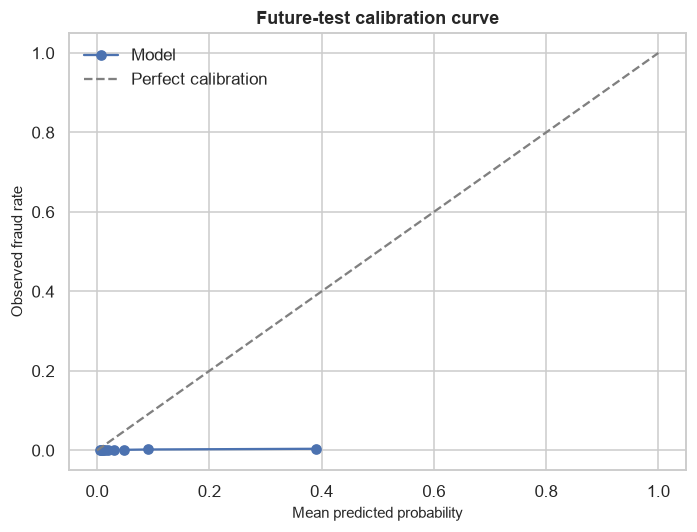

,Year,Rows,Fraud,Fraud_Rate_%,PR_AUC,ROC_AUC,Recall,Precision
0,2017,55336,16,0.0289,0.0014,0.8187,0.0000,0.0000
1,2018,85598,131,0.1530,0.0187,0.7921,0.0305,0.0193
2,2019,86057,109,0.1267,0.0039,0.7706,0.0000,0.0000


In [36]:
# ---------- Calibration and temporal stability diagnostics ----------
# Probability calibration is reported as a diagnostic. No calibration method is tuned on the test set.
prob_true, prob_pred = calibration_curve(
    y_test,
    test_proba,
    n_bins=10,
    strategy="quantile",
)
brier = brier_score_loss(y_test, test_proba)
print(f"Future-test Brier score: {brier:.6f}")

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(prob_pred, prob_true, marker="o", label="Model")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraud rate")
ax.set_title("Future-test calibration curve")
ax.legend()
plt.tight_layout()
plt.show()

# Performance by calendar year on the future test, when enough fraud cases exist.
if "Year" in X_test.columns:
    yearly_rows = []
    for year, idx in X_test.groupby("Year").groups.items():
        y_year = y_test.loc[idx]
        if int(y_year.sum()) < 5:
            continue
        p_year = test_proba[X_test.index.get_indexer(idx)]
        yearly_rows.append({
            "Year": year,
            "Rows": len(idx),
            "Fraud": int(y_year.sum()),
            "Fraud_Rate_%": 100 * float(y_year.mean()),
            "PR_AUC": average_precision_score(y_year, p_year),
            "ROC_AUC": roc_auc_score(y_year, p_year),
            "Recall": recall_score(y_year, (p_year >= selected_threshold).astype(int), zero_division=0),
            "Precision": precision_score(y_year, (p_year >= selected_threshold).astype(int), zero_division=0),
        })
    if yearly_rows:
        display(pd.DataFrame(yearly_rows).sort_values("Year"))


# 19. Final Conclusions

All numerical conclusions below are generated from the current execution, not copied from a previous run.


In [37]:
print(f"""
FINAL CONCLUSIONS (generated from this run)
===========================================
* Data: {len(df):,} prepared transactions, {n_fraud:,} fraudulent ({fraud_rate:.4%}).
* Primary protocol: chronological training -> validation -> future test; the future test was not used for model or threshold selection.
* Selected model: {final_model_name}.
* Threshold: {selected_threshold:.4f} ({threshold_note}).
* Future-test PR-AUC: {test_metrics['PR_AUC']:.4f}.
* Future-test ROC-AUC: {test_metrics['ROC_AUC']:.4f}.
* Future-test precision at the selected threshold: {test_metrics['Precision']:.4f}.
* Future-test recall at the selected threshold: {test_metrics['Recall']:.4f}.
* Future-test F1 at the selected threshold: {test_metrics['F1']:.4f}.
* Future-test false positives: {test_metrics['FP']:,}.
* Future-test false negatives: {test_metrics['FN']:,}.
* Future-test Brier score: {brier:.6f}.

Interpretation:
The future-period metrics are the main estimate of deployment-like performance. Any substantially higher
random-split benchmark should be treated as an optimism diagnostic rather than as the expected production result.
Threshold values are operating assumptions, not universal fraud-policy recommendations.
""")



FINAL CONCLUSIONS (generated from this run)
* Data: 1,219,345 prepared transactions, 1,481 fraudulent (0.1215%).
* Primary protocol: chronological training -> validation -> future test; the future test was not used for model or threshold selection.
* Selected model: HistGradientBoosting (tuned).
* Threshold: 0.9600 (maximum F1 on out-of-fold development predictions).
* Future-test PR-AUC: 0.0087.
* Future-test ROC-AUC: 0.7846.
* Future-test precision at the selected threshold: 0.0070.
* Future-test recall at the selected threshold: 0.0156.
* Future-test F1 at the selected threshold: 0.0097.
* Future-test false positives: 565.
* Future-test false negatives: 252.
* Future-test Brier score: 0.023121.

Interpretation:
The future-period metrics are the main estimate of deployment-like performance. Any substantially higher
random-split benchmark should be treated as an optimism diagnostic rather than as the expected production result.
Threshold values are operating assumptions, not universa

# 20. Production Considerations

This notebook is **production-oriented code structure**, not a deployed fraud decisioning system.

Key production requirements include:
- Forward-chaining evaluation on matured fraud labels.
- Account/card/time-aware leakage controls appropriate to the deployment scenario.
- Monitoring of PR-AUC, recall at fixed alert rate, precision in review, alert volume and score drift.
- Data-quality checks for schema, missingness, category drift, timestamp freshness and amount ranges.
- Versioned feature code, model artifacts and dataset snapshots.
- Model-risk, privacy, security and regulatory review before operational use.
- Champion/challenger testing, rollback capability and human-review controls.


In [38]:
# ---------- Final results summary ----------
best_cv = cv_scores.get(final_model_name)
summary_rows = [
    ("Prepared rows", f"{len(df):,}"),
    ("Fraud count", f"{n_fraud:,}"),
    ("Fraud percentage", f"{fraud_rate:.4%}"),
    ("Primary evaluation", "Chronological train -> validation -> future test"),
    ("Training-core rows used for CV", f"{len(X_tr):,}"),
    ("Development rows used for final refit", f"{len(X_dev):,}"),
    ("Future-test rows", f"{len(X_test):,}"),
    ("Selected model", final_model_name),
    ("Best time-series CV PR-AUC", f"{best_cv:.4f}" if best_cv is not None else "n/a"),
    ("Selected threshold", f"{selected_threshold:.4f}"),
    ("Threshold policy", threshold_note),
    ("Future-test PR-AUC", f"{test_metrics['PR_AUC']:.4f}"),
    ("Future-test ROC-AUC", f"{test_metrics['ROC_AUC']:.4f}"),
    ("Future-test precision", f"{test_metrics['Precision']:.4f}"),
    ("Future-test recall", f"{test_metrics['Recall']:.4f}"),
    ("Future-test F1", f"{test_metrics['F1']:.4f}"),
    ("Future-test false positives", f"{test_metrics['FP']:,}"),
    ("Future-test false negatives", f"{test_metrics['FN']:,}"),
    ("Future-test Brier score", f"{brier:.6f}"),
]
display(pd.DataFrame(summary_rows, columns=["Metric", "Value"]).set_index("Metric"))
print("The future-test metrics are the primary deployment-like estimate in this notebook.")
print("Any random-split benchmark should be treated as a diagnostic, not as the main performance claim.")


,Value
Metric,
Prepared rows,"1,219,345"
Fraud count,"1,481"
Fraud percentage,0.1215%
Primary evaluation,Chronological train -> validation -> future test
Training-core rows used for CV,"300,000"
Development rows used for final refit,"975,476"
Future-test rows,"243,869"
Selected model,HistGradientBoosting (tuned)
Best time-series CV PR-AUC,0.1701


The future-test metrics are the primary deployment-like estimate in this notebook.
Any random-split benchmark should be treated as a diagnostic, not as the main performance claim.
